In [2]:
from pathlib import Path

import pandas as pd

from IPython.display import display
from sklearn.model_selection import train_test_split


# Buscar el corpus según la ubicación del notebook actual
rutas_posibles = [
    Path("corpus_normalizado.pkl"),
    Path("../Lab1/corpus_normalizado.pkl"),
    Path("Lab1/corpus_normalizado.pkl")
]

ruta_corpus = next(
    (
        ruta
        for ruta in rutas_posibles
        if ruta.exists()
    ),
    None
)

if ruta_corpus is None:
    raise FileNotFoundError(
        "No se encontró 'corpus_normalizado.pkl'."
    )

corpus = pd.read_pickle(
    ruta_corpus
)

columnas_requeridas = [
    "url",
    "news",
    "Type",
    "tokens_lematizados",
    "News_normalizada"
]

columnas_faltantes = [
    columna
    for columna in columnas_requeridas
    if columna not in corpus.columns
]

if columnas_faltantes:
    raise ValueError(
        f"Faltan columnas necesarias: {columnas_faltantes}"
    )

semilla_aleatoria = 42

# Agrupar documentos con el mismo texto normalizado
clave_texto = (
    corpus["News_normalizada"]
    .fillna("")
    .str.strip()
)

tabla_grupos_texto = (
    corpus
    .assign(_clave_texto=clave_texto)
    .groupby(
        "_clave_texto",
        sort=False
    )
    .agg(
        Categoria_estratificacion=(
            "Type",
            lambda categorias:
                categorias.mode().iloc[0]
        ),
        Cantidad_documentos=(
            "Type",
            "size"
        )
    )
    .reset_index()
)

# Separar los grupos en entrenamiento y conjunto temporal
grupos_entrenamiento, grupos_temporales = (
    train_test_split(
        tabla_grupos_texto,
        test_size=0.30,
        random_state=semilla_aleatoria,
        stratify=tabla_grupos_texto[
            "Categoria_estratificacion"
        ]
    )
)

# Dividir el conjunto temporal entre validación y prueba
grupos_validacion, grupos_prueba = (
    train_test_split(
        grupos_temporales,
        test_size=0.50,
        random_state=semilla_aleatoria,
        stratify=grupos_temporales[
            "Categoria_estratificacion"
        ]
    )
)

claves_entrenamiento = set(
    grupos_entrenamiento["_clave_texto"]
)

claves_validacion = set(
    grupos_validacion["_clave_texto"]
)

claves_prueba = set(
    grupos_prueba["_clave_texto"]
)

corpus_entrenamiento = corpus.loc[
    clave_texto.isin(
        claves_entrenamiento
    )
].copy()

corpus_validacion = corpus.loc[
    clave_texto.isin(
        claves_validacion
    )
].copy()

corpus_prueba = corpus.loc[
    clave_texto.isin(
        claves_prueba
    )
].copy()

intersecciones_texto = {
    "Entrenamiento - Validación": len(
        claves_entrenamiento
        & claves_validacion
    ),
    "Entrenamiento - Prueba": len(
        claves_entrenamiento
        & claves_prueba
    ),
    "Validación - Prueba": len(
        claves_validacion
        & claves_prueba
    )
}

if (
    len(corpus_entrenamiento)
    + len(corpus_validacion)
    + len(corpus_prueba)
    != len(corpus)
):
    raise AssertionError(
        "Las particiones no contienen todos los documentos."
    )

if not all(
    cantidad == 0
    for cantidad in intersecciones_texto.values()
):
    raise AssertionError(
        "Existen textos normalizados compartidos "
        "entre las particiones."
    )

resumen_particiones = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Validación",
        "Prueba"
    ],
    "Cantidad de documentos": [
        len(corpus_entrenamiento),
        len(corpus_validacion),
        len(corpus_prueba)
    ]
})

resumen_particiones["Porcentaje del corpus"] = (
    resumen_particiones[
        "Cantidad de documentos"
    ]
    / len(corpus)
    * 100
).round(2)

print(
    f"Corpus cargado desde: {ruta_corpus.resolve()}"
)

display(
    resumen_particiones
)

print("Textos normalizados compartidos entre conjuntos:")

for comparacion, cantidad in (
    intersecciones_texto.items()
):
    print(f"{comparacion}: {cantidad}")

Corpus cargado desde: /Users/josetanchez/Desktop/NLP-Labs-JoseTanchez/Lab1/corpus_normalizado.pkl


,Conjunto,Cantidad de documentos,Porcentaje del corpus
0,Entrenamiento,850,69.84
1,Validación,185,15.20
2,Prueba,182,14.95


Textos normalizados compartidos entre conjuntos:
Entrenamiento - Validación: 0
Entrenamiento - Prueba: 0
Validación - Prueba: 0


In [3]:
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)


textos_entrenamiento = (
    corpus_entrenamiento[
        "News_normalizada"
    ]
    .fillna("")
)

textos_validacion = (
    corpus_validacion[
        "News_normalizada"
    ]
    .fillna("")
)

textos_prueba = (
    corpus_prueba[
        "News_normalizada"
    ]
    .fillna("")
)

etiquetas_entrenamiento = (
    corpus_entrenamiento["Type"]
)

etiquetas_validacion = (
    corpus_validacion["Type"]
)

etiquetas_prueba = (
    corpus_prueba["Type"]
)

orden_categorias = (
    corpus["Type"]
    .value_counts()
    .index
    .tolist()
)

# Bolsa de Palabras
vectorizador_bow = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

matriz_bow_entrenamiento = (
    vectorizador_bow.fit_transform(
        textos_entrenamiento
    )
)

matriz_bow_validacion = (
    vectorizador_bow.transform(
        textos_validacion
    )
)

matriz_bow_prueba = (
    vectorizador_bow.transform(
        textos_prueba
    )
)

vocabulario_bow = (
    vectorizador_bow.get_feature_names_out()
)

# TF-IDF
vectorizador_tfidf = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False
)

matriz_tfidf_entrenamiento = (
    vectorizador_tfidf.fit_transform(
        textos_entrenamiento
    )
)

matriz_tfidf_validacion = (
    vectorizador_tfidf.transform(
        textos_validacion
    )
)

matriz_tfidf_prueba = (
    vectorizador_tfidf.transform(
        textos_prueba
    )
)

vocabulario_tfidf = (
    vectorizador_tfidf.get_feature_names_out()
)

if not (
    matriz_bow_entrenamiento.shape[0]
    == len(etiquetas_entrenamiento)
    and matriz_bow_validacion.shape[0]
    == len(etiquetas_validacion)
    and matriz_bow_prueba.shape[0]
    == len(etiquetas_prueba)
):
    raise AssertionError(
        "Las matrices BoW no coinciden con sus etiquetas."
    )

if not (
    matriz_tfidf_entrenamiento.shape[0]
    == len(etiquetas_entrenamiento)
    and matriz_tfidf_validacion.shape[0]
    == len(etiquetas_validacion)
    and matriz_tfidf_prueba.shape[0]
    == len(etiquetas_prueba)
):
    raise AssertionError(
        "Las matrices TF-IDF no coinciden con sus etiquetas."
    )

if not (
    matriz_bow_entrenamiento.shape[1]
    == matriz_bow_validacion.shape[1]
    == matriz_bow_prueba.shape[1]
    == len(vocabulario_bow)
):
    raise AssertionError(
        "Las matrices BoW no comparten el mismo vocabulario."
    )

if not (
    matriz_tfidf_entrenamiento.shape[1]
    == matriz_tfidf_validacion.shape[1]
    == matriz_tfidf_prueba.shape[1]
    == len(vocabulario_tfidf)
):
    raise AssertionError(
        "Las matrices TF-IDF no comparten "
        "el mismo vocabulario."
    )

resumen_representaciones = pd.DataFrame({
    "Representación": [
        "BoW",
        "TF-IDF"
    ],
    "Entrenamiento": [
        str(matriz_bow_entrenamiento.shape),
        str(matriz_tfidf_entrenamiento.shape)
    ],
    "Validación": [
        str(matriz_bow_validacion.shape),
        str(matriz_tfidf_validacion.shape)
    ],
    "Prueba": [
        str(matriz_bow_prueba.shape),
        str(matriz_tfidf_prueba.shape)
    ],
    "Tamaño del vocabulario": [
        len(vocabulario_bow),
        len(vocabulario_tfidf)
    ]
})

display(
    resumen_representaciones
)

,Representación,Entrenamiento,Validación,Prueba,Tamaño del vocabulario
0,BoW,"(850, 17922)","(185, 17922)","(182, 17922)",17922
1,TF-IDF,"(850, 17922)","(185, 17922)","(182, 17922)",17922


In [4]:
from sklearn.linear_model import LogisticRegression


modelo_regresion_logistica_bow = (
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=semilla_aleatoria
    )
)

modelo_regresion_logistica_bow.fit(
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

print(
    "Modelo de Regresión Logística "
    "con BoW entrenado correctamente."
)

print(
    "Cantidad de categorías aprendidas:",
    len(
        modelo_regresion_logistica_bow.classes_
    )
)

print("Categorías aprendidas:")

print(
    modelo_regresion_logistica_bow.classes_
)

Modelo de Regresión Logística con BoW entrenado correctamente.
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']


In [5]:
modelo_regresion_logistica_tfidf = (
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=semilla_aleatoria
    )
)

modelo_regresion_logistica_tfidf.fit(
    matriz_tfidf_entrenamiento,
    etiquetas_entrenamiento
)

print(
    "Modelo de Regresión Logística "
    "con TF-IDF entrenado correctamente."
)

print(
    "Cantidad de categorías aprendidas:",
    len(
        modelo_regresion_logistica_tfidf.classes_
    )
)

print("Categorías aprendidas:")

print(
    modelo_regresion_logistica_tfidf.classes_
)

Modelo de Regresión Logística con TF-IDF entrenado correctamente.
Cantidad de categorías aprendidas: 7
Categorías aprendidas:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']


In [6]:
verificaciones_clasificadores = {
    "Ambos modelos aprendieron las mismas categorías": (
        modelo_regresion_logistica_bow
        .classes_
        .tolist()
        == modelo_regresion_logistica_tfidf
        .classes_
        .tolist()
    ),
    "BoW contiene una fila de pesos por categoría": (
        modelo_regresion_logistica_bow
        .coef_
        .shape[0]
        == len(
            modelo_regresion_logistica_bow
            .classes_
        )
    ),
    "TF-IDF contiene una fila de pesos por categoría": (
        modelo_regresion_logistica_tfidf
        .coef_
        .shape[0]
        == len(
            modelo_regresion_logistica_tfidf
            .classes_
        )
    ),
    "Los pesos de BoW coinciden con su vocabulario": (
        modelo_regresion_logistica_bow
        .coef_
        .shape[1]
        == len(vocabulario_bow)
    ),
    "Los pesos de TF-IDF coinciden con su vocabulario": (
        modelo_regresion_logistica_tfidf
        .coef_
        .shape[1]
        == len(vocabulario_tfidf)
    ),
    "BoW convergió antes del límite de iteraciones": (
        modelo_regresion_logistica_bow
        .n_iter_
        .max()
        < modelo_regresion_logistica_bow
        .max_iter
    ),
    "TF-IDF convergió antes del límite de iteraciones": (
        modelo_regresion_logistica_tfidf
        .n_iter_
        .max()
        < modelo_regresion_logistica_tfidf
        .max_iter
    )
}

tabla_verificacion_clasificadores = pd.DataFrame({
    "Verificación":
        verificaciones_clasificadores.keys(),
    "Resultado": [
        "Correcto" if resultado else "Error"
        for resultado
        in verificaciones_clasificadores.values()
    ]
})

if not all(
    verificaciones_clasificadores.values()
):
    raise AssertionError(
        "Una o más verificaciones de los "
        "clasificadores fallaron."
    )

resumen_clasificadores = pd.DataFrame({
    "Modelo": [
        "Regresión Logística + BoW",
        "Regresión Logística + TF-IDF"
    ],
    "Categorías": [
        len(
            modelo_regresion_logistica_bow
            .classes_
        ),
        len(
            modelo_regresion_logistica_tfidf
            .classes_
        )
    ],
    "Forma de coef_": [
        str(
            modelo_regresion_logistica_bow
            .coef_
            .shape
        ),
        str(
            modelo_regresion_logistica_tfidf
            .coef_
            .shape
        )
    ],
    "Forma de intercept_": [
        str(
            modelo_regresion_logistica_bow
            .intercept_
            .shape
        ),
        str(
            modelo_regresion_logistica_tfidf
            .intercept_
            .shape
        )
    ],
    "Iteraciones": [
        int(
            modelo_regresion_logistica_bow
            .n_iter_
            .max()
        ),
        int(
            modelo_regresion_logistica_tfidf
            .n_iter_
            .max()
        )
    ]
})

display(
    resumen_clasificadores
)

display(
    tabla_verificacion_clasificadores
)

print(
    "Los dos clasificadores se construyeron "
    "y verificaron correctamente."
)

,Modelo,Categorías,Forma de coef_,Forma de intercept_,Iteraciones
0,Regresión Logística + BoW,7,"(7, 17922)","(7,)",66
1,Regresión Logística + TF-IDF,7,"(7, 17922)","(7,)",31


,Verificación,Resultado
0,Ambos modelos aprendieron las mismas categorías,Correcto
1,BoW contiene una fila de pesos por categoría,Correcto
2,TF-IDF contiene una fila de pesos por categoría,Correcto
3,Los pesos de BoW coinciden con su vocabulario,Correcto
4,Los pesos de TF-IDF coinciden con su vocabulario,Correcto
5,BoW convergió antes del límite de iteraciones,Correcto
6,TF-IDF convergió antes del límite de iteraciones,Correcto


Los dos clasificadores se construyeron y verificaron correctamente.


# 1. Construcción del clasificador de Regresión Logística

Se construyeron dos clasificadores de Regresión Logística para predecir la categoría de cada noticia:

1. Regresión Logística con Bolsa de Palabras.
2. Regresión Logística con TF-IDF.

Se conservaron el corpus, las particiones y la configuración de los vectorizadores utilizados en el Laboratorio 3. De esta forma, los clasificadores lineales y los modelos de Naive Bayes utilizan los mismos documentos y espacios de características.

## 1.1 Preparación de los datos

El corpus contiene **1,217 documentos**, distribuidos mediante una división estratificada y reproducible con `random_state=42`.

| Conjunto | Documentos | Porcentaje |
|---|---:|---:|
| Entrenamiento | 850 | 69.84 % |
| Validación | 185 | 15.20 % |
| Prueba | 182 | 14.95 % |

Los documentos con el mismo texto normalizado se mantuvieron dentro de una sola partición. Las intersecciones entre entrenamiento, validación y prueba fueron iguales a cero, por lo que no existen textos normalizados compartidos entre conjuntos.

Los vectorizadores se ajustaron exclusivamente con los documentos de entrenamiento. Los conjuntos de validación y prueba se transformaron sin modificar el vocabulario aprendido.

| Representación | Entrenamiento | Validación | Prueba | Vocabulario |
|---|---|---|---|---:|
| BoW | (850, 17,922) | (185, 17,922) | (182, 17,922) | 17,922 |
| TF-IDF | (850, 17,922) | (185, 17,922) | (182, 17,922) | 17,922 |

## 1.2 Regresión Logística con BoW

El primer clasificador se entrenó con `matriz_bow_entrenamiento`, que representa cada noticia mediante los conteos de sus palabras.

Se utilizó `LogisticRegression` con el optimizador `lbfgs` y un máximo de 1,000 iteraciones. El modelo aprendió las siete categorías del corpus:

- `Alianzas`
- `Innovacion`
- `Macroeconomia`
- `Otra`
- `Regulaciones`
- `Reputacion`
- `Sostenibilidad`

El entrenamiento convergió después de **66 iteraciones**. La matriz `coef_` tiene forma **(7, 17,922)**, correspondiente a una fila de pesos por categoría y una columna por característica. El vector `intercept_` tiene forma **(7,)**.

## 1.3 Regresión Logística con TF-IDF

El segundo clasificador se entrenó con `matriz_tfidf_entrenamiento`. En esta representación, las palabras reciben valores de acuerdo con su importancia dentro de cada documento y su frecuencia en el conjunto de entrenamiento.

Se utilizó la misma configuración de Regresión Logística. El modelo también aprendió las siete categorías y convergió después de **31 iteraciones**.

Su matriz `coef_` tiene forma **(7, 17,922)** y su vector `intercept_` tiene forma **(7,)**. Por lo tanto, cada categoría cuenta con un peso para cada término del vocabulario y con su propio intercepto.

## 1.4 Interpretación del modelo lineal

La operación fundamental de un clasificador lineal puede expresarse como:


En el contexto de la clasificación de noticias:

- \(\mathbf{x}\) representa las características de una noticia. Sus componentes son conteos de palabras en BoW o valores TF-IDF.
- \(\mathbf{w}\) representa los pesos aprendidos para las características.
- \(b\) representa el intercepto aprendido por el modelo.
- \(z\) representa el puntaje lineal producido para una categoría.

Un peso positivo aumenta el puntaje de una categoría cuando la característica aparece en el documento, mientras que un peso negativo lo reduce.

En un problema binario, la función sigmoide permite transformar un puntaje lineal en un valor entre cero y uno:



Este valor puede interpretarse como la probabilidad estimada de la clase positiva. Posteriormente, la probabilidad se utiliza para obtener una predicción.

En este corpus existen siete categorías, por lo que el problema es multiclase. La configuración utilizada con `lbfgs` aplica una estrategia multinomial: se calcula un puntaje para cada categoría \(c\):



Los siete puntajes se normalizan conjuntamente mediante la función softmax:



De esta manera, las probabilidades de todas las categorías suman uno. La predicción final corresponde a la categoría con la probabilidad más alta:



La sigmoide describe el caso binario fundamental, mientras que softmax constituye su extensión coherente para la clasificación multinomial utilizada en este laboratorio.

## 1.5 Verificación de los clasificadores

Las verificaciones confirmaron que:

1. Ambos modelos aprendieron exactamente las mismas siete categorías.
2. Cada categoría posee su propia fila de coeficientes.
3. Los coeficientes de cada modelo coinciden con las 17,922 características de su vectorizador.
4. Cada modelo posee siete interceptos.
5. Ambos entrenamientos convergieron antes del límite de 1,000 iteraciones.
6. Los modelos fueron entrenados únicamente con los 850 documentos del conjunto de entrenamiento.

Por lo tanto, los clasificadores de Regresión Logística con BoW y TF-IDF quedaron construidos correctamente y preparados para su evaluación posterior.

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


def calcular_metricas_clasificacion(
    etiquetas_reales,
    predicciones
):
    """
    Calcula las métricas generales de clasificación.
    """

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            etiquetas_reales,
            predicciones,
            average="macro",
            zero_division=0
        )
    )

    (
        precision_ponderada,
        recall_ponderado,
        f1_ponderado,
        _
    ) = precision_recall_fscore_support(
        etiquetas_reales,
        predicciones,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy_score(
            etiquetas_reales,
            predicciones
        ),
        "Precisión macro": precision_macro,
        "Recall macro": recall_macro,
        "F1 macro": f1_macro,
        "Precisión ponderada":
            precision_ponderada,
        "Recall ponderado":
            recall_ponderado,
        "F1 ponderado":
            f1_ponderado
    }


print(
    "Función de métricas creada correctamente."
)

Función de métricas creada correctamente.


In [8]:
# Predicciones de Regresión Logística con BoW
predicciones_regresion_logistica_bow_entrenamiento = (
    modelo_regresion_logistica_bow.predict(
        matriz_bow_entrenamiento
    )
)

predicciones_regresion_logistica_bow_validacion = (
    modelo_regresion_logistica_bow.predict(
        matriz_bow_validacion
    )
)

predicciones_regresion_logistica_bow_prueba = (
    modelo_regresion_logistica_bow.predict(
        matriz_bow_prueba
    )
)

# Predicciones de Regresión Logística con TF-IDF
predicciones_regresion_logistica_tfidf_entrenamiento = (
    modelo_regresion_logistica_tfidf.predict(
        matriz_tfidf_entrenamiento
    )
)

predicciones_regresion_logistica_tfidf_validacion = (
    modelo_regresion_logistica_tfidf.predict(
        matriz_tfidf_validacion
    )
)

predicciones_regresion_logistica_tfidf_prueba = (
    modelo_regresion_logistica_tfidf.predict(
        matriz_tfidf_prueba
    )
)


def construir_resultados_regresion_logistica(
    nombre_modelo,
    predicciones_entrenamiento,
    predicciones_validacion,
    predicciones_prueba
):
    """
    Consolida las métricas de los tres conjuntos.
    """

    return pd.DataFrame([
        {
            "Modelo": nombre_modelo,
            "Conjunto": "Entrenamiento",
            **calcular_metricas_clasificacion(
                etiquetas_entrenamiento,
                predicciones_entrenamiento
            )
        },
        {
            "Modelo": nombre_modelo,
            "Conjunto": "Validación",
            **calcular_metricas_clasificacion(
                etiquetas_validacion,
                predicciones_validacion
            )
        },
        {
            "Modelo": nombre_modelo,
            "Conjunto": "Prueba",
            **calcular_metricas_clasificacion(
                etiquetas_prueba,
                predicciones_prueba
            )
        }
    ])


resultados_regresion_logistica_bow = (
    construir_resultados_regresion_logistica(
        nombre_modelo=(
            "Regresión Logística + BoW"
        ),
        predicciones_entrenamiento=(
            predicciones_regresion_logistica_bow_entrenamiento
        ),
        predicciones_validacion=(
            predicciones_regresion_logistica_bow_validacion
        ),
        predicciones_prueba=(
            predicciones_regresion_logistica_bow_prueba
        )
    )
)

resultados_regresion_logistica_tfidf = (
    construir_resultados_regresion_logistica(
        nombre_modelo=(
            "Regresión Logística + TF-IDF"
        ),
        predicciones_entrenamiento=(
            predicciones_regresion_logistica_tfidf_entrenamiento
        ),
        predicciones_validacion=(
            predicciones_regresion_logistica_tfidf_validacion
        ),
        predicciones_prueba=(
            predicciones_regresion_logistica_tfidf_prueba
        )
    )
)

resultados_regresion_logistica = pd.concat(
    [
        resultados_regresion_logistica_bow,
        resultados_regresion_logistica_tfidf
    ],
    ignore_index=True
)

display(
    resultados_regresion_logistica.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "Precisión ponderada": 4,
        "Recall ponderado": 4,
        "F1 ponderado": 4
    })
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,Regresión Logística + BoW,Entrenamiento,0.9976,0.9978,0.9976,0.9977,0.9977,0.9976,0.9976
1,Regresión Logística + BoW,Validación,0.8486,0.8768,0.7881,0.8149,0.8551,0.8486,0.8448
2,Regresión Logística + BoW,Prueba,0.8516,0.8592,0.8188,0.8343,0.8522,0.8516,0.8494
3,Regresión Logística + TF-IDF,Entrenamiento,0.9518,0.9653,0.8788,0.9053,0.9545,0.9518,0.9495
4,Regresión Logística + TF-IDF,Validación,0.8378,0.7528,0.7012,0.7101,0.8412,0.8378,0.8239
5,Regresión Logística + TF-IDF,Prueba,0.8022,0.8546,0.6890,0.7111,0.8327,0.8022,0.7870


In [9]:
from sklearn.metrics import classification_report


if (
    modelo_regresion_logistica_bow
    .classes_
    .tolist()
    != modelo_regresion_logistica_tfidf
    .classes_
    .tolist()
):
    raise ValueError(
        "Los modelos utilizan órdenes "
        "de categorías diferentes."
    )

clases_regresion_logistica = (
    modelo_regresion_logistica_bow
    .classes_
)

conjuntos_reportes_regresion_logistica = [
    (
        "Regresión Logística + BoW",
        "Entrenamiento",
        etiquetas_entrenamiento,
        predicciones_regresion_logistica_bow_entrenamiento
    ),
    (
        "Regresión Logística + BoW",
        "Validación",
        etiquetas_validacion,
        predicciones_regresion_logistica_bow_validacion
    ),
    (
        "Regresión Logística + BoW",
        "Prueba",
        etiquetas_prueba,
        predicciones_regresion_logistica_bow_prueba
    ),
    (
        "Regresión Logística + TF-IDF",
        "Entrenamiento",
        etiquetas_entrenamiento,
        predicciones_regresion_logistica_tfidf_entrenamiento
    ),
    (
        "Regresión Logística + TF-IDF",
        "Validación",
        etiquetas_validacion,
        predicciones_regresion_logistica_tfidf_validacion
    ),
    (
        "Regresión Logística + TF-IDF",
        "Prueba",
        etiquetas_prueba,
        predicciones_regresion_logistica_tfidf_prueba
    )
]

reportes_clasificacion_regresion_logistica = {}

for (
    nombre_modelo,
    nombre_conjunto,
    etiquetas_reales,
    predicciones
) in conjuntos_reportes_regresion_logistica:
    reporte_texto = classification_report(
        etiquetas_reales,
        predicciones,
        labels=clases_regresion_logistica,
        target_names=clases_regresion_logistica,
        digits=4,
        zero_division=0
    )

    reporte_diccionario = classification_report(
        etiquetas_reales,
        predicciones,
        labels=clases_regresion_logistica,
        target_names=clases_regresion_logistica,
        output_dict=True,
        zero_division=0
    )

    reportes_clasificacion_regresion_logistica[
        (
            nombre_modelo,
            nombre_conjunto
        )
    ] = pd.DataFrame(
        reporte_diccionario
    ).T

    print(
        f"{nombre_modelo.upper()} — "
        f"{nombre_conjunto.upper()}\n"
    )

    print(
        reporte_texto
    )

REGRESIÓN LOGÍSTICA + BOW — ENTRENAMIENTO

                precision    recall  f1-score   support

      Alianzas     1.0000    0.9942    0.9971       173
    Innovacion     1.0000    1.0000    1.0000       138
 Macroeconomia     0.9958    1.0000    0.9979       239
          Otra     0.9890    1.0000    0.9945        90
  Regulaciones     1.0000    1.0000    1.0000        99
    Reputacion     1.0000    1.0000    1.0000        18
Sostenibilidad     1.0000    0.9892    0.9946        93

      accuracy                         0.9976       850
     macro avg     0.9978    0.9976    0.9977       850
  weighted avg     0.9977    0.9976    0.9976       850

REGRESIÓN LOGÍSTICA + BOW — VALIDACIÓN

                precision    recall  f1-score   support

      Alianzas     0.7907    0.9189    0.8500        37
    Innovacion     0.8125    0.9286    0.8667        28
 Macroeconomia     0.8679    0.9020    0.8846        51
          Otra     0.8500    0.8500    0.8500        20
  Regulaciones   

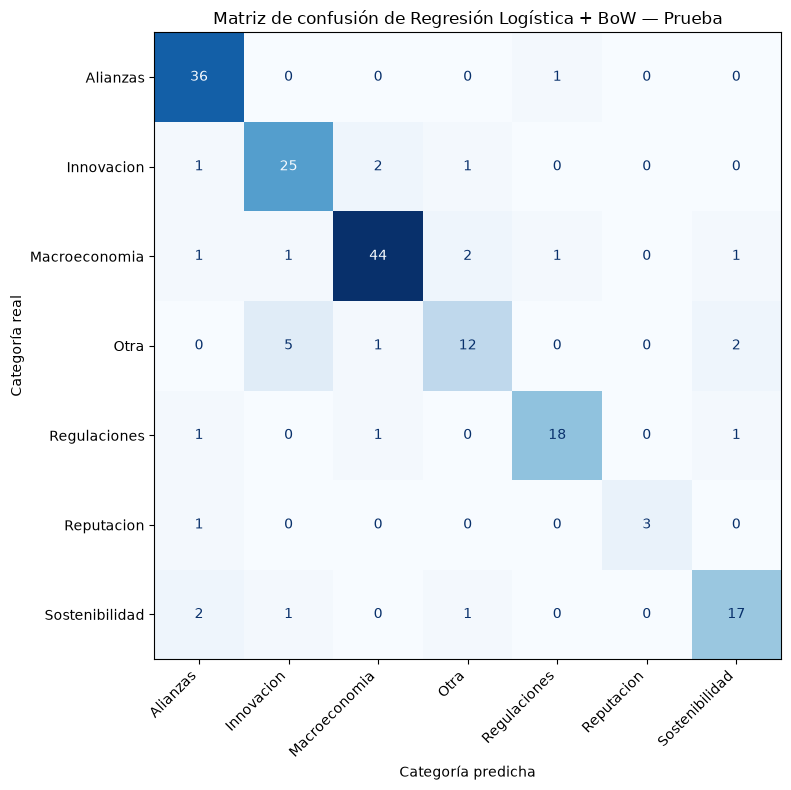

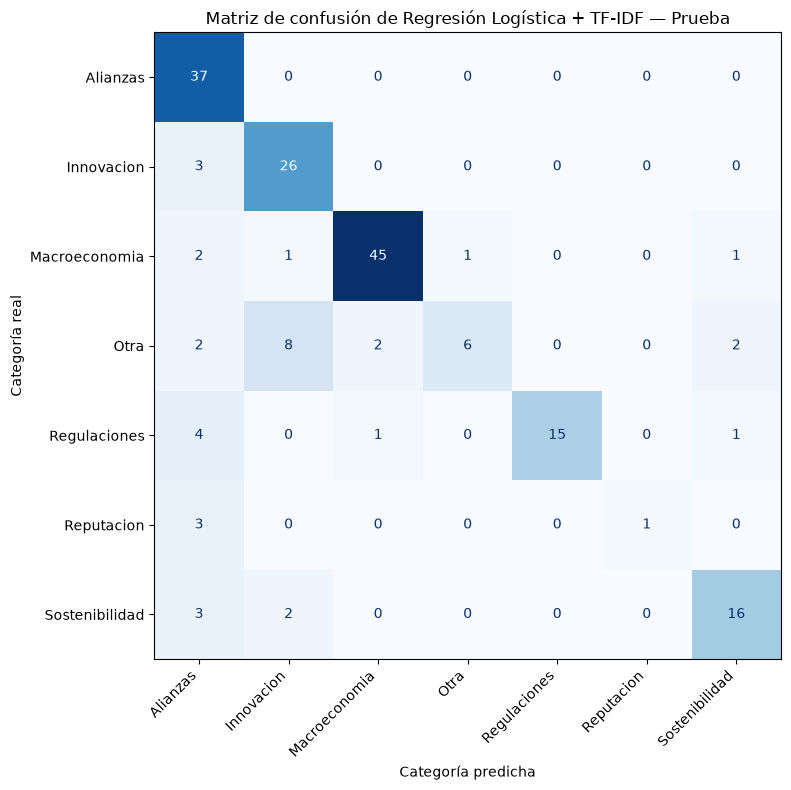

In [10]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)


matriz_confusion_regresion_logistica_bow_prueba = (
    confusion_matrix(
        etiquetas_prueba,
        predicciones_regresion_logistica_bow_prueba,
        labels=clases_regresion_logistica
    )
)

matriz_confusion_regresion_logistica_tfidf_prueba = (
    confusion_matrix(
        etiquetas_prueba,
        predicciones_regresion_logistica_tfidf_prueba,
        labels=clases_regresion_logistica
    )
)

matrices_confusion_regresion_logistica_prueba = {
    "Regresión Logística + BoW": (
        matriz_confusion_regresion_logistica_bow_prueba
    ),
    "Regresión Logística + TF-IDF": (
        matriz_confusion_regresion_logistica_tfidf_prueba
    )
}

for nombre_modelo, matriz_confusion_modelo in (
    matrices_confusion_regresion_logistica_prueba.items()
):
    fig, ax = plt.subplots(
        figsize=(11, 8)
    )

    visualizacion = ConfusionMatrixDisplay(
        confusion_matrix=matriz_confusion_modelo,
        display_labels=clases_regresion_logistica
    )

    visualizacion.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.title(
        f"Matriz de confusión de "
        f"{nombre_modelo} — Prueba"
    )

    plt.xlabel(
        "Categoría predicha"
    )

    plt.ylabel(
        "Categoría real"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

In [11]:
resultados_validacion_regresion_logistica = (
    resultados_regresion_logistica
    .loc[
        resultados_regresion_logistica[
            "Conjunto"
        ].eq("Validación")
    ]
    .copy()
    .sort_values(
        "F1 macro",
        ascending=False
    )
    .reset_index(drop=True)
)

indice_mejor_validacion = (
    resultados_validacion_regresion_logistica[
        "F1 macro"
    ].idxmax()
)

nombre_mejor_modelo_regresion_logistica = (
    resultados_validacion_regresion_logistica
    .loc[
        indice_mejor_validacion,
        "Modelo"
    ]
)

configuraciones_regresion_logistica = {
    "Regresión Logística + BoW": {
        "representacion": "BoW",
        "modelo":
            modelo_regresion_logistica_bow,
        "vectorizador":
            vectorizador_bow,
        "matriz_entrenamiento":
            matriz_bow_entrenamiento,
        "matriz_validacion":
            matriz_bow_validacion,
        "matriz_prueba":
            matriz_bow_prueba,
        "predicciones_entrenamiento":
            predicciones_regresion_logistica_bow_entrenamiento,
        "predicciones_validacion":
            predicciones_regresion_logistica_bow_validacion,
        "predicciones_prueba":
            predicciones_regresion_logistica_bow_prueba,
        "matriz_confusion_prueba":
            matriz_confusion_regresion_logistica_bow_prueba
    },
    "Regresión Logística + TF-IDF": {
        "representacion": "TF-IDF",
        "modelo":
            modelo_regresion_logistica_tfidf,
        "vectorizador":
            vectorizador_tfidf,
        "matriz_entrenamiento":
            matriz_tfidf_entrenamiento,
        "matriz_validacion":
            matriz_tfidf_validacion,
        "matriz_prueba":
            matriz_tfidf_prueba,
        "predicciones_entrenamiento":
            predicciones_regresion_logistica_tfidf_entrenamiento,
        "predicciones_validacion":
            predicciones_regresion_logistica_tfidf_validacion,
        "predicciones_prueba":
            predicciones_regresion_logistica_tfidf_prueba,
        "matriz_confusion_prueba":
            matriz_confusion_regresion_logistica_tfidf_prueba
    }
}

mejor_configuracion_regresion_logistica = (
    configuraciones_regresion_logistica[
        nombre_mejor_modelo_regresion_logistica
    ]
)

mejor_representacion_regresion_logistica = (
    mejor_configuracion_regresion_logistica[
        "representacion"
    ]
)

mejor_modelo_regresion_logistica = (
    mejor_configuracion_regresion_logistica[
        "modelo"
    ]
)

mejor_vectorizador_regresion_logistica = (
    mejor_configuracion_regresion_logistica[
        "vectorizador"
    ]
)

matriz_mejor_modelo_regresion_logistica_entrenamiento = (
    mejor_configuracion_regresion_logistica[
        "matriz_entrenamiento"
    ]
)

matriz_mejor_modelo_regresion_logistica_validacion = (
    mejor_configuracion_regresion_logistica[
        "matriz_validacion"
    ]
)

matriz_mejor_modelo_regresion_logistica_prueba = (
    mejor_configuracion_regresion_logistica[
        "matriz_prueba"
    ]
)

predicciones_mejor_modelo_regresion_logistica_prueba = (
    mejor_configuracion_regresion_logistica[
        "predicciones_prueba"
    ]
)

matriz_confusion_mejor_modelo_regresion_logistica_prueba = (
    mejor_configuracion_regresion_logistica[
        "matriz_confusion_prueba"
    ]
)

resultado_prueba_mejor_modelo_regresion_logistica = (
    resultados_regresion_logistica
    .loc[
        resultados_regresion_logistica[
            "Modelo"
        ].eq(
            nombre_mejor_modelo_regresion_logistica
        )
        & resultados_regresion_logistica[
            "Conjunto"
        ].eq("Prueba")
    ]
    .copy()
)

print(
    "Comparación mediante el conjunto de validación:"
)

display(
    resultados_validacion_regresion_logistica.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "Precisión ponderada": 4,
        "Recall ponderado": 4,
        "F1 ponderado": 4
    })
)

print(
    "Modelo seleccionado:",
    nombre_mejor_modelo_regresion_logistica
)

print(
    "Criterio de selección: "
    "mayor F1 macro de validación."
)

print(
    "\nResultado final del modelo "
    "seleccionado sobre prueba:"
)

display(
    resultado_prueba_mejor_modelo_regresion_logistica.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "Precisión ponderada": 4,
        "Recall ponderado": 4,
        "F1 ponderado": 4
    })
)

Comparación mediante el conjunto de validación:


,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,Regresión Logística + BoW,Validación,0.8486,0.8768,0.7881,0.8149,0.8551,0.8486,0.8448
1,Regresión Logística + TF-IDF,Validación,0.8378,0.7528,0.7012,0.7101,0.8412,0.8378,0.8239


Modelo seleccionado: Regresión Logística + BoW
Criterio de selección: mayor F1 macro de validación.

Resultado final del modelo seleccionado sobre prueba:


,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
2,Regresión Logística + BoW,Prueba,0.8516,0.8592,0.8188,0.8343,0.8522,0.8516,0.8494


# 2. Entrenamiento y evaluación

Los clasificadores de Regresión Logística con BoW y TF-IDF se evaluaron sobre los conjuntos de entrenamiento, validación y prueba.

La selección de la representación se realizó mediante el **F1 macro de validación**, de manera que el conjunto de prueba se mantuviera exclusivamente como evaluación final.

## 2.1 Resultados generales

Las métricas obtenidas fueron:

| Modelo | Conjunto | Accuracy | Precisión macro | Recall macro | F1 macro | Precisión ponderada | Recall ponderado | F1 ponderado |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Regresión Logística + BoW | Entrenamiento | 0.9976 | 0.9978 | 0.9976 | 0.9977 | 0.9977 | 0.9976 | 0.9976 |
| Regresión Logística + BoW | Validación | 0.8486 | 0.8768 | 0.7881 | 0.8149 | 0.8551 | 0.8486 | 0.8448 |
| Regresión Logística + BoW | Prueba | 0.8516 | 0.8592 | 0.8188 | 0.8343 | 0.8522 | 0.8516 | 0.8494 |
| Regresión Logística + TF-IDF | Entrenamiento | 0.9518 | 0.9653 | 0.8788 | 0.9053 | 0.9545 | 0.9518 | 0.9495 |
| Regresión Logística + TF-IDF | Validación | 0.8378 | 0.7528 | 0.7012 | 0.7101 | 0.8412 | 0.8378 | 0.8239 |
| Regresión Logística + TF-IDF | Prueba | 0.8022 | 0.8546 | 0.6890 | 0.7111 | 0.8327 | 0.8022 | 0.7870 |

BoW obtuvo el mayor `accuracy`, F1 macro y F1 ponderado en validación. En prueba también superó a TF-IDF en estas tres métricas.

La diferencia entre entrenamiento y validación muestra que ambos modelos disminuyen su desempeño al clasificar documentos no vistos. En BoW, el `accuracy` disminuye de **0.9976** a **0.8486**; en TF-IDF disminuye de **0.9518** a **0.8378**. Esto deja evidencia de posible sobreajuste, especialmente porque los resultados de entrenamiento son considerablemente más altos.

Sin embargo, el desempeño de BoW se mantiene estable entre validación y prueba, con un `accuracy` de **0.8486** y **0.8516**, respectivamente.

## 2.2 Resultados por categoría sobre prueba

### Regresión Logística con BoW

| Categoría | Precisión | Recall | F1-score | Documentos |
|---|---:|---:|---:|---:|
| Alianzas | 0.8571 | 0.9730 | 0.9114 | 37 |
| Innovacion | 0.7812 | 0.8621 | 0.8197 | 29 |
| Macroeconomia | 0.9167 | 0.8800 | 0.8980 | 50 |
| Otra | 0.7500 | 0.6000 | 0.6667 | 20 |
| Regulaciones | 0.9000 | 0.8571 | 0.8780 | 21 |
| Reputacion | 1.0000 | 0.7500 | 0.8571 | 4 |
| Sostenibilidad | 0.8095 | 0.8095 | 0.8095 | 21 |
| **Macro average** | **0.8592** | **0.8188** | **0.8343** | **182** |
| **Weighted average** | **0.8522** | **0.8516** | **0.8494** | **182** |

La categoría con mayor F1-score fue `Alianzas`, con **0.9114**, seguida de `Macroeconomia`, con **0.8980**. El menor F1-score correspondió a `Otra`, con **0.6667**, principalmente por su recall de **0.6000**.

La categoría `Reputacion` obtuvo una precisión de **1.0000**, aunque su soporte es de solamente cuatro documentos, por lo que el resultado debe interpretarse considerando su baja representación.

### Regresión Logística con TF-IDF

| Categoría | Precisión | Recall | F1-score | Documentos |
|---|---:|---:|---:|---:|
| Alianzas | 0.6852 | 1.0000 | 0.8132 | 37 |
| Innovacion | 0.7027 | 0.8966 | 0.7879 | 29 |
| Macroeconomia | 0.9375 | 0.9000 | 0.9184 | 50 |
| Otra | 0.8571 | 0.3000 | 0.4444 | 20 |
| Regulaciones | 1.0000 | 0.7143 | 0.8333 | 21 |
| Reputacion | 1.0000 | 0.2500 | 0.4000 | 4 |
| Sostenibilidad | 0.8000 | 0.7619 | 0.7805 | 21 |
| **Macro average** | **0.8546** | **0.6890** | **0.7111** | **182** |
| **Weighted average** | **0.8327** | **0.8022** | **0.7870** | **182** |

TF-IDF obtuvo su mayor F1-score en `Macroeconomia`, con **0.9184**. También identificó todos los documentos de `Alianzas`, alcanzando un recall de **1.0000**, aunque su precisión fue de **0.6852**.

Los valores más bajos se observaron en `Reputacion` y `Otra`, con F1-scores de **0.4000** y **0.4444**, respectivamente. El recall de `Otra` fue **0.3000**, lo que indica que únicamente seis de sus veinte documentos fueron clasificados correctamente.

## 2.3 Matrices de confusión

Se generó una matriz de confusión sobre prueba para cada representación. En ambas matrices:

- Las filas representan las categorías reales.
- Las columnas representan las categorías predichas.
- El orden de las categorías se obtuvo directamente de `classes_`.

El orden utilizado fue:

1. `Alianzas`
2. `Innovacion`
3. `Macroeconomia`
4. `Otra`
5. `Regulaciones`
6. `Reputacion`
7. `Sostenibilidad`

### Regresión Logística con BoW

La matriz de BoW contiene **155 predicciones correctas** y **27 errores**. La mayor confusión individual corresponde a cinco documentos de `Otra` clasificados como `Innovacion`.

La diagonal presenta resultados altos para `Alianzas`, `Macroeconomia`, `Regulaciones` y `Sostenibilidad`. La categoría `Otra` registra doce predicciones correctas de veinte documentos.

### Regresión Logística con TF-IDF

La matriz de TF-IDF contiene **146 predicciones correctas** y **36 errores**. Su mayor confusión individual corresponde a ocho documentos de `Otra` clasificados como `Innovacion`.

Los 37 documentos de `Alianzas` fueron identificados correctamente. Sin embargo, distintos documentos de otras categorías también fueron asignados a `Alianzas`, lo que explica la diferencia entre su recall de **1.0000** y su precisión de **0.6852**.

## 2.4 Selección de la representación

La selección se realizó mediante el F1 macro de validación:

| Representación | Accuracy | F1 macro | F1 ponderado |
|---|---:|---:|---:|
| BoW | 0.8486 | 0.8149 | 0.8448 |
| TF-IDF | 0.8378 | 0.7101 | 0.8239 |

La representación seleccionada fue **BoW**, con un F1 macro de validación de **0.8149**, frente a **0.7101** de TF-IDF.

Su evaluación final sobre los 182 documentos de prueba produjo:

- **Accuracy:** 0.8516
- **Precisión macro:** 0.8592
- **Recall macro:** 0.8188
- **F1 macro:** 0.8343
- **Precisión ponderada:** 0.8522
- **Recall ponderado:** 0.8516
- **F1 ponderado:** 0.8494

Por lo tanto, `modelo_regresion_logistica_bow` se conserva como el mejor clasificador de Regresión Logística para las secciones posteriores.

In [12]:
import numpy as np


if (
    mejor_representacion_regresion_logistica
    != "BoW"
):
    raise ValueError(
        "La representación seleccionada no es BoW."
    )

modelo_interpretado_regresion_logistica = (
    mejor_modelo_regresion_logistica
)

vectorizador_interpretado_regresion_logistica = (
    mejor_vectorizador_regresion_logistica
)

vocabulario_interpretado_regresion_logistica = (
    vectorizador_interpretado_regresion_logistica
    .get_feature_names_out()
)

if (
    modelo_interpretado_regresion_logistica
    .coef_
    .shape[1]
    != len(
        vocabulario_interpretado_regresion_logistica
    )
):
    raise ValueError(
        "Los coeficientes no coinciden "
        "con el vocabulario."
    )

categorias_interpretacion = (
    corpus["Type"]
    .value_counts()
    .head(3)
    .index
    .tolist()
)

categorias_no_disponibles = [
    categoria
    for categoria in categorias_interpretacion
    if categoria
    not in modelo_interpretado_regresion_logistica
    .classes_
]

if categorias_no_disponibles:
    raise ValueError(
        "Existen categorías sin coeficientes: "
        f"{categorias_no_disponibles}"
    )

resumen_categorias_interpretacion = []

for categoria in categorias_interpretacion:
    posicion_coeficiente = int(
        np.flatnonzero(
            modelo_interpretado_regresion_logistica
            .classes_
            == categoria
        )[0]
    )

    resumen_categorias_interpretacion.append({
        "Categoría": categoria,
        "Documentos en el corpus": int(
            corpus["Type"]
            .eq(categoria)
            .sum()
        ),
        "Documentos de entrenamiento": int(
            etiquetas_entrenamiento
            .eq(categoria)
            .sum()
        ),
        "Fila correspondiente en coef_":
            posicion_coeficiente
    })

tabla_categorias_interpretacion = (
    pd.DataFrame(
        resumen_categorias_interpretacion
    )
)

print(
    "Modelo interpretado:",
    nombre_mejor_modelo_regresion_logistica
)

display(
    tabla_categorias_interpretacion
)

Modelo interpretado: Regresión Logística + BoW


,Categoría,Documentos en el corpus,Documentos de entrenamiento,Fila correspondiente en coef_
0,Macroeconomia,340,239,2
1,Alianzas,247,173,0
2,Innovacion,195,138,1


In [13]:
cantidad_caracteristicas_interpretacion = 15

tablas_pesos_regresion_logistica = {}
registros_pesos_regresion_logistica = []

for categoria in categorias_interpretacion:
    posicion_categoria = int(
        np.flatnonzero(
            modelo_interpretado_regresion_logistica
            .classes_
            == categoria
        )[0]
    )

    pesos_categoria = (
        modelo_interpretado_regresion_logistica
        .coef_[
            posicion_categoria
        ]
    )

    indices_pesos_positivos = np.argsort(
        -pesos_categoria,
        kind="stable"
    )[
        :cantidad_caracteristicas_interpretacion
    ]

    indices_pesos_negativos = np.argsort(
        pesos_categoria,
        kind="stable"
    )[
        :cantidad_caracteristicas_interpretacion
    ]

    tabla_categoria = pd.DataFrame({
        "Característica positiva": (
            vocabulario_interpretado_regresion_logistica[
                indices_pesos_positivos
            ]
        ),
        "Peso positivo": (
            pesos_categoria[
                indices_pesos_positivos
            ]
        ),
        "Característica negativa": (
            vocabulario_interpretado_regresion_logistica[
                indices_pesos_negativos
            ]
        ),
        "Peso negativo": (
            pesos_categoria[
                indices_pesos_negativos
            ]
        )
    })

    tabla_categoria.index = range(
        1,
        len(tabla_categoria) + 1
    )

    tabla_categoria.index.name = "Posición"

    tablas_pesos_regresion_logistica[
        categoria
    ] = tabla_categoria

    for posicion in range(
        cantidad_caracteristicas_interpretacion
    ):
        registros_pesos_regresion_logistica.extend([
            {
                "Categoría": categoria,
                "Tipo de peso": "Positivo",
                "Posición": posicion + 1,
                "Característica": (
                    vocabulario_interpretado_regresion_logistica[
                        indices_pesos_positivos[
                            posicion
                        ]
                    ]
                ),
                "Peso": (
                    pesos_categoria[
                        indices_pesos_positivos[
                            posicion
                        ]
                    ]
                )
            },
            {
                "Categoría": categoria,
                "Tipo de peso": "Negativo",
                "Posición": posicion + 1,
                "Característica": (
                    vocabulario_interpretado_regresion_logistica[
                        indices_pesos_negativos[
                            posicion
                        ]
                    ]
                ),
                "Peso": (
                    pesos_categoria[
                        indices_pesos_negativos[
                            posicion
                        ]
                    ]
                )
            }
        ])

tabla_pesos_regresion_logistica = pd.DataFrame(
    registros_pesos_regresion_logistica
)

print(
    "Características positivas y negativas "
    "calculadas para:",
    ", ".join(categorias_interpretacion)
)

Características positivas y negativas calculadas para: Macroeconomia, Alianzas, Innovacion


In [14]:
from sklearn.naive_bayes import MultinomialNB


modelo_bow = MultinomialNB(
    alpha=1.0
)

modelo_bow.fit(
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

if (
    modelo_bow.classes_.tolist()
    != modelo_interpretado_regresion_logistica
    .classes_
    .tolist()
):
    raise ValueError(
        "Naive Bayes y Regresión Logística "
        "utilizan órdenes de categorías diferentes."
    )

if (
    modelo_bow.feature_log_prob_.shape[1]
    != len(vocabulario_bow)
):
    raise ValueError(
        "Las probabilidades de Naive Bayes "
        "no coinciden con el vocabulario BoW."
    )

cantidad_palabras_naive_bayes = 15

tablas_palabras_probables_naive_bayes = {}
registros_palabras_probables_naive_bayes = []

for categoria in categorias_interpretacion:
    posicion_categoria = int(
        np.flatnonzero(
            modelo_bow.classes_
            == categoria
        )[0]
    )

    log_probabilidades_categoria = (
        modelo_bow.feature_log_prob_[
            posicion_categoria
        ]
    )

    probabilidades_categoria = np.exp(
        log_probabilidades_categoria
    )

    indices_mayores = np.argsort(
        -probabilidades_categoria,
        kind="stable"
    )[
        :cantidad_palabras_naive_bayes
    ]

    tabla_categoria = pd.DataFrame({
        "Palabra con mayor P(w_i | c)": (
            vocabulario_bow[
                indices_mayores
            ]
        ),
        "P(w_i | c)": (
            probabilidades_categoria[
                indices_mayores
            ]
        ),
        "log P(w_i | c)": (
            log_probabilidades_categoria[
                indices_mayores
            ]
        )
    })

    tabla_categoria.index = range(
        1,
        len(tabla_categoria) + 1
    )

    tabla_categoria.index.name = "Posición"

    tablas_palabras_probables_naive_bayes[
        categoria
    ] = tabla_categoria

    for posicion, indice_palabra in enumerate(
        indices_mayores,
        start=1
    ):
        registros_palabras_probables_naive_bayes.append({
            "Categoría": categoria,
            "Posición": posicion,
            "Palabra": vocabulario_bow[
                indice_palabra
            ],
            "P(w_i | c)": (
                probabilidades_categoria[
                    indice_palabra
                ]
            ),
            "log P(w_i | c)": (
                log_probabilidades_categoria[
                    indice_palabra
                ]
            )
        })

tabla_palabras_probables_naive_bayes = (
    pd.DataFrame(
        registros_palabras_probables_naive_bayes
    )
)

sumas_probabilidades_naive_bayes = np.exp(
    modelo_bow.feature_log_prob_
).sum(axis=1)

if not np.allclose(
    sumas_probabilidades_naive_bayes,
    1.0
):
    raise AssertionError(
        "Las probabilidades condicionales "
        "de Naive Bayes no suman uno."
    )

print(
    "Modelo Naive Bayes + BoW "
    "reconstruido correctamente."
)

print(
    "Las probabilidades condicionales "
    "suman uno para todas las categorías."
)

Modelo Naive Bayes + BoW reconstruido correctamente.
Las probabilidades condicionales suman uno para todas las categorías.


In [15]:
comparaciones_pesos_naive_bayes = {}

for categoria in categorias_interpretacion:
    tabla_comparacion = pd.concat(
        [
            tablas_pesos_regresion_logistica[
                categoria
            ],
            tablas_palabras_probables_naive_bayes[
                categoria
            ]
        ],
        axis=1
    )

    comparaciones_pesos_naive_bayes[
        categoria
    ] = tabla_comparacion

    print(
        f"CATEGORÍA: {categoria}\n"
    )

    display(
        tabla_comparacion.round({
            "Peso positivo": 6,
            "Peso negativo": 6,
            "P(w_i | c)": 8,
            "log P(w_i | c)": 6
        })
    )

tabla_comparacion_interpretacion = pd.concat(
    comparaciones_pesos_naive_bayes,
    names=[
        "Categoría",
        "Posición"
    ]
)

CATEGORÍA: Macroeconomia



,Característica positiva,Peso positivo,Característica negativa,Peso negativo,Palabra con mayor P(w_i | c),P(w_i | c),log P(w_i | c)
Posición,,,,,,,
1,inflación,0.459385,persona,-0.261987,inflación,0.011209,-4.491032
2,aumento,0.299770,usuario,-0.256638,precio,0.008663,-4.748675
3,precio,0.290828,alianza,-0.248225,año,0.008345,-4.786102
4,economía,0.288114,hacer,-0.233174,poder,0.005823,-5.146010
5,ipc,0.246529,compañía,-0.223030,bbva,0.004715,-5.357081
6,seguro,0.224114,digital,-0.203023,mayor,0.004514,-5.400511
7,bbva,0.216263,empresa,-0.198914,mes,0.004420,-5.421620
8,consumidor,0.206153,sostenible,-0.196291,tasa,0.004149,-5.484915
9,economista,0.197528,regulación,-0.183283,él,0.003984,-5.525500


CATEGORÍA: Alianzas



,Característica positiva,Peso positivo,Característica negativa,Peso negativo,Palabra con mayor P(w_i | c),P(w_i | c),log P(w_i | c)
Posición,,,,,,,
1,alianza,1.062262,bbva,-0.718474,alianza,0.005511,-5.200995
2,compañía,0.333818,regulación,-0.269141,país,0.004655,-5.369894
3,colombia,0.265961,reputación,-0.160522,poder,0.004468,-5.410716
4,anunciar,0.262564,si,-0.153510,millón,0.004357,-5.436033
5,acceso,0.233843,españa,-0.145849,colombia,0.003947,-5.534768
6,acuerdo,0.229763,sistema,-0.133212,año,0.003742,-5.588050
7,colombiano,0.223932,importante,-0.130254,él,0.003444,-5.670999
8,perú,0.204733,aumento,-0.128552,nuevo,0.003165,-5.755556
9,programa,0.199338,social,-0.126995,mercado,0.002904,-5.841498


CATEGORÍA: Innovacion



,Característica positiva,Peso positivo,Característica negativa,Peso negativo,Palabra con mayor P(w_i | c),P(w_i | c),log P(w_i | c)
Posición,,,,,,,
1,bbva,0.606018,colombia,-0.284403,bbva,0.013470,-4.307320
2,podcast,0.298144,país,-0.236439,poder,0.006297,-5.067676
3,capital,0.282537,sostenible,-0.199215,él,0.005775,-5.154201
4,importante,0.262165,manera,-0.197096,banco,0.005152,-5.268347
5,talento,0.241656,director,-0.192211,cliente,0.004782,-5.342957
6,summit,0.235701,educación,-0.189289,digital,0.004445,-5.415983
7,teléfono,0.212785,además,-0.172147,nuevo,0.004142,-5.486600
8,agile,0.211680,producto,-0.168837,financiero,0.003974,-5.528100
9,pago,0.204567,alianza,-0.159505,empresa,0.003805,-5.571397


In [16]:
coincidencias_interpretacion = []

for categoria in categorias_interpretacion:
    tabla_pesos_categoria = (
        tablas_pesos_regresion_logistica[
            categoria
        ]
    )

    tabla_naive_bayes_categoria = (
        tablas_palabras_probables_naive_bayes[
            categoria
        ]
    )

    palabras_positivas = (
        tabla_pesos_categoria[
            "Característica positiva"
        ]
        .tolist()
    )

    palabras_negativas = (
        tabla_pesos_categoria[
            "Característica negativa"
        ]
        .tolist()
    )

    palabras_naive_bayes = (
        tabla_naive_bayes_categoria[
            "Palabra con mayor P(w_i | c)"
        ]
        .tolist()
    )

    conjunto_palabras_naive_bayes = set(
        palabras_naive_bayes
    )

    coincidencias_positivas = [
        palabra
        for palabra in palabras_positivas
        if palabra
        in conjunto_palabras_naive_bayes
    ]

    coincidencias_negativas = [
        palabra
        for palabra in palabras_negativas
        if palabra
        in conjunto_palabras_naive_bayes
    ]

    coincidencias_interpretacion.append({
        "Categoría": categoria,
        "Cantidad de coincidencias positivas": (
            len(coincidencias_positivas)
        ),
        "Coincidencias positivas": (
            ", ".join(coincidencias_positivas)
            if coincidencias_positivas
            else "Ninguna"
        ),
        "Cantidad de coincidencias negativas": (
            len(coincidencias_negativas)
        ),
        "Coincidencias negativas": (
            ", ".join(coincidencias_negativas)
            if coincidencias_negativas
            else "Ninguna"
        )
    })

tabla_coincidencias_interpretacion = (
    pd.DataFrame(
        coincidencias_interpretacion
    )
)

display(
    tabla_coincidencias_interpretacion
)

,Categoría,Cantidad de coincidencias positivas,Coincidencias positivas,Cantidad de coincidencias negativas,Coincidencias negativas
0,Macroeconomia,5,"inflación, aumento, precio, bbva, crecimiento",0,Ninguna
1,Alianzas,4,"alianza, compañía, colombia, millón",1,hacer
2,Innovacion,1,bbva,0,Ninguna


# 3. Interpretación de pesos

La interpretación se realizó sobre **Regresión Logística + BoW**, seleccionada previamente mediante el F1 macro de validación.

La matriz `coef_` contiene una fila de pesos por categoría y una columna por cada una de las 17,922 características del vocabulario. La correspondencia entre filas y categorías se verificó directamente mediante `classes_`.

Se seleccionaron las tres categorías con mayor cantidad de documentos:

| Categoría | Documentos del corpus | Documentos de entrenamiento | Fila en `coef_` |
|---|---:|---:|---:|
| Macroeconomia | 340 | 239 | 2 |
| Alianzas | 247 | 173 | 0 |
| Innovacion | 195 | 138 | 1 |

Los índices de las características se asociaron con sus términos mediante `get_feature_names_out()`.

Un peso positivo incrementa el puntaje lineal de una categoría cuando la característica está presente. Un peso negativo reduce ese puntaje y representa evidencia a favor de otras categorías. El signo del coeficiente no indica necesariamente que una palabra nunca aparezca en la categoría, sino su contribución discriminativa dentro del modelo multiclase.

## 3.1 Pesos de Macroeconomia

| Posición | Característica positiva | Peso positivo | Característica negativa | Peso negativo | Mayor \(P(w_i\mid c)\) en Naive Bayes | \(P(w_i\mid c)\) |
|---:|---|---:|---|---:|---|---:|
| 1 | inflación | 0.459385 | persona | -0.261987 | inflación | 0.011209 |
| 2 | aumento | 0.299770 | usuario | -0.256638 | precio | 0.008663 |
| 3 | precio | 0.290828 | alianza | -0.248225 | año | 0.008345 |
| 4 | economía | 0.288114 | hacer | -0.233174 | poder | 0.005823 |
| 5 | ipc | 0.246529 | compañía | -0.223030 | bbva | 0.004715 |
| 6 | seguro | 0.224114 | digital | -0.203023 | mayor | 0.004514 |
| 7 | bbva | 0.216263 | empresa | -0.198914 | mes | 0.004420 |
| 8 | consumidor | 0.206153 | sostenible | -0.196291 | tasa | 0.004149 |
| 9 | economista | 0.197528 | regulación | -0.183283 | él | 0.003984 |
| 10 | 2022 | 0.190977 | colombia | -0.180454 | crecimiento | 0.003630 |
| 11 | 2023 | 0.190333 | seguridad | -0.174368 | país | 0.003595 |
| 12 | crecimiento | 0.188939 | entidad | -0.170715 | aumento | 0.003359 |
| 13 | publicado | 0.186600 | grupo | -0.165613 | económico | 0.003288 |
| 14 | incremento | 0.178851 | tecnológico | -0.161292 | alimento | 0.003241 |
| 15 | decisión | 0.178615 | plataforma | -0.159484 | banco | 0.003182 |

Las características positivas contienen términos directamente relacionados con indicadores económicos, como `inflación`, `precio`, `economía`, `ipc`, `consumidor`, `economista` y `crecimiento`.

Los pesos negativos incluyen palabras como `alianza`, `digital`, `sostenible`, `regulación` y `tecnológico`, relacionadas con temas representados por otras categorías.

## 3.2 Pesos de Alianzas

| Posición | Característica positiva | Peso positivo | Característica negativa | Peso negativo | Mayor \(P(w_i\mid c)\) en Naive Bayes | \(P(w_i\mid c)\) |
|---:|---|---:|---|---:|---|---:|
| 1 | alianza | 1.062262 | bbva | -0.718474 | alianza | 0.005511 |
| 2 | compañía | 0.333818 | regulación | -0.269141 | país | 0.004655 |
| 3 | colombia | 0.265961 | reputación | -0.160522 | poder | 0.004468 |
| 4 | anunciar | 0.262564 | si | -0.153510 | millón | 0.004357 |
| 5 | acceso | 0.233843 | españa | -0.145849 | colombia | 0.003947 |
| 6 | acuerdo | 0.229763 | sistema | -0.133212 | año | 0.003742 |
| 7 | colombiano | 0.223932 | importante | -0.130254 | él | 0.003444 |
| 8 | perú | 0.204733 | aumento | -0.128552 | nuevo | 0.003165 |
| 9 | programa | 0.199338 | social | -0.126995 | mercado | 0.002904 |
| 10 | estratégico | 0.194218 | sector | -0.126760 | hacer | 0.002886 |
| 11 | político | 0.189739 | podcast | -0.123379 | empresa | 0.002793 |
| 12 | marca | 0.188041 | hacer | -0.119421 | primero | 0.002327 |
| 13 | estrategia | 0.185000 | principal | -0.116289 | servicio | 0.002216 |
| 14 | millón | 0.183019 | comisión | -0.114367 | compañía | 0.002104 |
| 15 | total | 0.181634 | hablar | -0.113611 | ser | 0.002067 |

`alianza` posee el mayor peso positivo de las tres categorías analizadas, con **1.062262**. También aparecen términos asociados con acuerdos y cooperación, como `compañía`, `anunciar`, `acceso`, `acuerdo`, `programa`, `estratégico` y `estrategia`.

`bbva` presenta el peso negativo más intenso de esta categoría, con **-0.718474**. Esto indica que, dentro del modelo multiclase, su presencia aporta más evidencia hacia otras categorías que hacia `Alianzas`.

## 3.3 Pesos de Innovacion

| Posición | Característica positiva | Peso positivo | Característica negativa | Peso negativo | Mayor \(P(w_i\mid c)\) en Naive Bayes | \(P(w_i\mid c)\) |
|---:|---|---:|---|---:|---|---:|
| 1 | bbva | 0.606018 | colombia | -0.284403 | bbva | 0.013470 |
| 2 | podcast | 0.298144 | país | -0.236439 | poder | 0.006297 |
| 3 | capital | 0.282537 | sostenible | -0.199215 | él | 0.005775 |
| 4 | importante | 0.262165 | manera | -0.197096 | banco | 0.005152 |
| 5 | talento | 0.241656 | director | -0.192211 | cliente | 0.004782 |
| 6 | summit | 0.235701 | educación | -0.189289 | digital | 0.004445 |
| 7 | teléfono | 0.212785 | además | -0.172147 | nuevo | 0.004142 |
| 8 | agile | 0.211680 | producto | -0.168837 | financiero | 0.003974 |
| 9 | pago | 0.204567 | alianza | -0.159505 | empresa | 0.003805 |
| 10 | usuario | 0.201199 | estrategia | -0.153614 | permitir | 0.003704 |
| 11 | perfil | 0.198486 | niño | -0.153075 | hacer | 0.003519 |
| 12 | innovación | 0.195310 | decir | -0.150497 | ser | 0.003098 |
| 13 | emprendimiento | 0.191805 | parte | -0.146693 | año | 0.002963 |
| 14 | seguridad | 0.188410 | asegurar | -0.135810 | servicio | 0.002946 |
| 15 | tecnología | 0.182932 | experto | -0.133518 | dato | 0.002761 |

Las características positivas incluyen términos asociados con tecnología, productos digitales y emprendimiento, como `podcast`, `talento`, `summit`, `teléfono`, `agile`, `usuario`, `innovación`, `emprendimiento` y `tecnología`.

Entre los pesos negativos aparecen `colombia`, `país`, `sostenible` y `alianza`. Estos términos pueden estar presentes en noticias de innovación, pero el modelo aprendió que aportan mayor evidencia relativa hacia otras categorías.

## 3.4 Comparación con Naive Bayes

El modelo Naive Bayes con BoW fue reconstruido con `alpha=1.0`, la misma matriz de entrenamiento y el mismo vocabulario del Laboratorio 3. Se verificó que las probabilidades condicionales suman uno para cada categoría.

Las coincidencias entre los 15 mayores pesos positivos de Regresión Logística y las 15 palabras con mayor \(P(w_i\mid c)\) fueron:

| Categoría | Coincidencias positivas | Cantidad | Coincidencias negativas | Cantidad |
|---|---|---:|---|---:|
| Macroeconomia | inflación, aumento, precio, bbva, crecimiento | 5 | Ninguna | 0 |
| Alianzas | alianza, compañía, colombia, millón | 4 | hacer | 1 |
| Innovacion | bbva | 1 | Ninguna | 0 |

En `Macroeconomia`, ambos modelos coinciden en términos temáticamente representativos como `inflación`, `precio` y `crecimiento`. En `Alianzas` coinciden principalmente en `alianza`, `compañía`, `colombia` y `millón`.

La menor coincidencia se encuentra en `Innovacion`, donde solamente `bbva` aparece en ambas listas. Regresión Logística asigna pesos positivos altos a características más específicas, como `podcast`, `talento`, `summit`, `agile`, `innovación`, `emprendimiento` y `tecnología`. En cambio, las probabilidades más altas de Naive Bayes incluyen términos frecuentes como `poder`, `él`, `banco`, `nuevo`, `empresa`, `hacer` y `año`.

También se observa que `hacer` aparece entre las palabras más probables de Naive Bayes para `Alianzas`, con \(P(w_i\mid c)=0.002886\), pero recibe un peso negativo de **-0.119421** en Regresión Logística. Esto muestra que una palabra puede ser frecuente dentro de una categoría sin proporcionar evidencia discriminativa a favor de ella cuando se considera su comportamiento frente a las demás categorías.

En conjunto, Naive Bayes destaca palabras con alta probabilidad dentro de cada categoría, mientras que Regresión Logística asigna pesos según la contribución de cada característica a la separación entre las siete clases.

In [17]:
verificaciones_comparacion_justa = {
    "Las representaciones usan el mismo entrenamiento": (
        matriz_bow_entrenamiento.shape[0]
        == matriz_tfidf_entrenamiento.shape[0]
        == len(etiquetas_entrenamiento)
        == 850
    ),
    "Las representaciones usan la misma validación": (
        matriz_bow_validacion.shape[0]
        == matriz_tfidf_validacion.shape[0]
        == len(etiquetas_validacion)
        == 185
    ),
    "Las representaciones usan la misma prueba": (
        matriz_bow_prueba.shape[0]
        == matriz_tfidf_prueba.shape[0]
        == len(etiquetas_prueba)
        == 182
    ),
    "BoW conserva el vocabulario de entrenamiento": (
        matriz_bow_entrenamiento.shape[1]
        == matriz_bow_validacion.shape[1]
        == matriz_bow_prueba.shape[1]
        == len(vocabulario_bow)
    ),
    "TF-IDF conserva el vocabulario de entrenamiento": (
        matriz_tfidf_entrenamiento.shape[1]
        == matriz_tfidf_validacion.shape[1]
        == matriz_tfidf_prueba.shape[1]
        == len(vocabulario_tfidf)
    ),
    "No existen textos compartidos entre conjuntos": (
        all(
            cantidad == 0
            for cantidad
            in intersecciones_texto.values()
        )
    ),
    "Todas las categorías aparecen en entrenamiento": (
        set(etiquetas_entrenamiento.unique())
        == set(orden_categorias)
    ),
    "Todas las categorías aparecen en prueba": (
        set(etiquetas_prueba.unique())
        == set(orden_categorias)
    )
}

tabla_verificacion_comparacion_justa = (
    pd.DataFrame({
        "Verificación":
            verificaciones_comparacion_justa.keys(),
        "Resultado": [
            "Correcto" if resultado else "Error"
            for resultado
            in verificaciones_comparacion_justa.values()
        ]
    })
)

if not all(
    verificaciones_comparacion_justa.values()
):
    raise AssertionError(
        "Una o más condiciones de la "
        "comparación justa no se cumplen."
    )

display(
    tabla_verificacion_comparacion_justa
)

,Verificación,Resultado
0,Las representaciones usan el mismo entrenamiento,Correcto
1,Las representaciones usan la misma validación,Correcto
2,Las representaciones usan la misma prueba,Correcto
3,BoW conserva el vocabulario de entrenamiento,Correcto
4,TF-IDF conserva el vocabulario de entrenamiento,Correcto
5,No existen textos compartidos entre conjuntos,Correcto
6,Todas las categorías aparecen en entrenamiento,Correcto
7,Todas las categorías aparecen en prueba,Correcto


In [18]:
import time


def entrenar_y_medir_tiempo(
    modelo,
    matriz_entrenamiento,
    etiquetas
):
    """
    Entrena un modelo y devuelve el tiempo
    aproximado utilizado por fit().
    """

    inicio = time.perf_counter()

    modelo.fit(
        matriz_entrenamiento,
        etiquetas
    )

    fin = time.perf_counter()

    return modelo, fin - inicio


modelo_comparacion_naive_bayes_bow = (
    MultinomialNB(
        alpha=1.0
    )
)

(
    modelo_comparacion_naive_bayes_bow,
    tiempo_entrenamiento_naive_bayes_bow
) = entrenar_y_medir_tiempo(
    modelo_comparacion_naive_bayes_bow,
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

modelo_comparacion_naive_bayes_tfidf = (
    MultinomialNB(
        alpha=1.0
    )
)

(
    modelo_comparacion_naive_bayes_tfidf,
    tiempo_entrenamiento_naive_bayes_tfidf
) = entrenar_y_medir_tiempo(
    modelo_comparacion_naive_bayes_tfidf,
    matriz_tfidf_entrenamiento,
    etiquetas_entrenamiento
)

modelo_comparacion_regresion_logistica_bow = (
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=semilla_aleatoria
    )
)

(
    modelo_comparacion_regresion_logistica_bow,
    tiempo_entrenamiento_regresion_logistica_bow
) = entrenar_y_medir_tiempo(
    modelo_comparacion_regresion_logistica_bow,
    matriz_bow_entrenamiento,
    etiquetas_entrenamiento
)

modelo_comparacion_regresion_logistica_tfidf = (
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=semilla_aleatoria
    )
)

(
    modelo_comparacion_regresion_logistica_tfidf,
    tiempo_entrenamiento_regresion_logistica_tfidf
) = entrenar_y_medir_tiempo(
    modelo_comparacion_regresion_logistica_tfidf,
    matriz_tfidf_entrenamiento,
    etiquetas_entrenamiento
)

tiempos_entrenamiento_modelos = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Naive Bayes",
        "Regresión Logística",
        "Regresión Logística"
    ],
    "Representación": [
        "BoW",
        "TF-IDF",
        "BoW",
        "TF-IDF"
    ],
    "Tiempo de entrenamiento (s)": [
        tiempo_entrenamiento_naive_bayes_bow,
        tiempo_entrenamiento_naive_bayes_tfidf,
        tiempo_entrenamiento_regresion_logistica_bow,
        tiempo_entrenamiento_regresion_logistica_tfidf
    ]
})

display(
    tiempos_entrenamiento_modelos.round({
        "Tiempo de entrenamiento (s)": 6
    })
)

,Modelo,Representación,Tiempo de entrenamiento (s)
0,Naive Bayes,BoW,0.109305
1,Naive Bayes,TF-IDF,0.019267
2,Regresión Logística,BoW,0.640830
3,Regresión Logística,TF-IDF,0.276125


In [19]:
predicciones_comparacion_naive_bayes_bow_prueba = (
    modelo_comparacion_naive_bayes_bow.predict(
        matriz_bow_prueba
    )
)

predicciones_comparacion_naive_bayes_tfidf_prueba = (
    modelo_comparacion_naive_bayes_tfidf.predict(
        matriz_tfidf_prueba
    )
)

predicciones_comparacion_regresion_logistica_bow_prueba = (
    modelo_comparacion_regresion_logistica_bow.predict(
        matriz_bow_prueba
    )
)

predicciones_comparacion_regresion_logistica_tfidf_prueba = (
    modelo_comparacion_regresion_logistica_tfidf.predict(
        matriz_tfidf_prueba
    )
)


def construir_fila_comparacion(
    nombre_modelo,
    representacion,
    predicciones,
    tiempo_entrenamiento
):
    metricas = calcular_metricas_clasificacion(
        etiquetas_prueba,
        predicciones
    )

    return {
        "Modelo": nombre_modelo,
        "Representación": representacion,
        "Accuracy": metricas["Accuracy"],
        "F1 macro": metricas["F1 macro"],
        "F1 ponderado":
            metricas["F1 ponderado"],
        "Tiempo de entrenamiento (s)":
            tiempo_entrenamiento
    }


tabla_comparativa_modelos = pd.DataFrame([
    construir_fila_comparacion(
        nombre_modelo="Naive Bayes",
        representacion="BoW",
        predicciones=(
            predicciones_comparacion_naive_bayes_bow_prueba
        ),
        tiempo_entrenamiento=(
            tiempo_entrenamiento_naive_bayes_bow
        )
    ),
    construir_fila_comparacion(
        nombre_modelo="Naive Bayes",
        representacion="TF-IDF",
        predicciones=(
            predicciones_comparacion_naive_bayes_tfidf_prueba
        ),
        tiempo_entrenamiento=(
            tiempo_entrenamiento_naive_bayes_tfidf
        )
    ),
    construir_fila_comparacion(
        nombre_modelo="Regresión Logística",
        representacion="BoW",
        predicciones=(
            predicciones_comparacion_regresion_logistica_bow_prueba
        ),
        tiempo_entrenamiento=(
            tiempo_entrenamiento_regresion_logistica_bow
        )
    ),
    construir_fila_comparacion(
        nombre_modelo="Regresión Logística",
        representacion="TF-IDF",
        predicciones=(
            predicciones_comparacion_regresion_logistica_tfidf_prueba
        ),
        tiempo_entrenamiento=(
            tiempo_entrenamiento_regresion_logistica_tfidf
        )
    )
])

display(
    tabla_comparativa_modelos.round({
        "Accuracy": 4,
        "F1 macro": 4,
        "F1 ponderado": 4,
        "Tiempo de entrenamiento (s)": 6
    })
)

,Modelo,Representación,Accuracy,F1 macro,F1 ponderado,Tiempo de entrenamiento (s)
0,Naive Bayes,BoW,0.8077,0.7305,0.7985,0.109305
1,Naive Bayes,TF-IDF,0.5714,0.3141,0.4564,0.019267
2,Regresión Logística,BoW,0.8516,0.8343,0.8494,0.640830
3,Regresión Logística,TF-IDF,0.8022,0.7111,0.7870,0.276125


In [20]:
orden_clases_comparacion = (
    modelo_comparacion_naive_bayes_bow
    .classes_
    .tolist()
)

modelos_comparacion = [
    modelo_comparacion_naive_bayes_bow,
    modelo_comparacion_naive_bayes_tfidf,
    modelo_comparacion_regresion_logistica_bow,
    modelo_comparacion_regresion_logistica_tfidf
]

verificaciones_resultados_comparacion = {
    "Los cuatro modelos usan las mismas categorías": (
        all(
            modelo.classes_.tolist()
            == orden_clases_comparacion
            for modelo in modelos_comparacion
        )
    ),
    "Naive Bayes + BoW reproduce el modelo del Lab 3": (
        np.array_equal(
            predicciones_comparacion_naive_bayes_bow_prueba,
            modelo_bow.predict(
                matriz_bow_prueba
            )
        )
    ),
    "Regresión Logística + BoW reproduce sus predicciones": (
        np.array_equal(
            predicciones_comparacion_regresion_logistica_bow_prueba,
            predicciones_regresion_logistica_bow_prueba
        )
    ),
    "Regresión Logística + TF-IDF reproduce sus predicciones": (
        np.array_equal(
            predicciones_comparacion_regresion_logistica_tfidf_prueba,
            predicciones_regresion_logistica_tfidf_prueba
        )
    ),
    "Todas las predicciones corresponden a prueba": (
        all(
            len(predicciones)
            == len(etiquetas_prueba)
            for predicciones in [
                predicciones_comparacion_naive_bayes_bow_prueba,
                predicciones_comparacion_naive_bayes_tfidf_prueba,
                predicciones_comparacion_regresion_logistica_bow_prueba,
                predicciones_comparacion_regresion_logistica_tfidf_prueba
            ]
        )
    ),
    "Todos los tiempos medidos son positivos": (
        all(
            tiempo > 0
            for tiempo in [
                tiempo_entrenamiento_naive_bayes_bow,
                tiempo_entrenamiento_naive_bayes_tfidf,
                tiempo_entrenamiento_regresion_logistica_bow,
                tiempo_entrenamiento_regresion_logistica_tfidf
            ]
        )
    )
}

tabla_verificacion_resultados_comparacion = (
    pd.DataFrame({
        "Verificación":
            verificaciones_resultados_comparacion.keys(),
        "Resultado": [
            "Correcto" if resultado else "Error"
            for resultado
            in verificaciones_resultados_comparacion.values()
        ]
    })
)

if not all(
    verificaciones_resultados_comparacion.values()
):
    raise AssertionError(
        "Una o más verificaciones de "
        "la comparación fallaron."
    )

display(
    tabla_verificacion_resultados_comparacion
)

,Verificación,Resultado
0,Los cuatro modelos usan las mismas categorías,Correcto
1,Naive Bayes + BoW reproduce el modelo del Lab 3,Correcto
2,Regresión Logística + BoW reproduce sus predic...,Correcto
3,Regresión Logística + TF-IDF reproduce sus pre...,Correcto
4,Todas las predicciones corresponden a prueba,Correcto
5,Todos los tiempos medidos son positivos,Correcto


In [21]:
tabla_comparativa_ordenada = (
    tabla_comparativa_modelos
    .sort_values(
        [
            "F1 macro",
            "Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

mejor_combinacion_prueba = (
    tabla_comparativa_ordenada
    .iloc[0]
)

segunda_combinacion_prueba = (
    tabla_comparativa_ordenada
    .iloc[1]
)

diferencia_f1_macro_mejores_modelos = (
    mejor_combinacion_prueba[
        "F1 macro"
    ]
    - segunda_combinacion_prueba[
        "F1 macro"
    ]
)

display(
    tabla_comparativa_ordenada.round({
        "Accuracy": 4,
        "F1 macro": 4,
        "F1 ponderado": 4,
        "Tiempo de entrenamiento (s)": 6
    })
)

print(
    "Combinación con mayor F1 macro de prueba:"
)

print(
    f"{mejor_combinacion_prueba['Modelo']} + "
    f"{mejor_combinacion_prueba['Representación']}"
)

print(
    "Diferencia de F1 macro respecto "
    "a la segunda combinación:",
    f"{diferencia_f1_macro_mejores_modelos:.4f}"
)

,Modelo,Representación,Accuracy,F1 macro,F1 ponderado,Tiempo de entrenamiento (s)
0,Regresión Logística,BoW,0.8516,0.8343,0.8494,0.640830
1,Naive Bayes,BoW,0.8077,0.7305,0.7985,0.109305
2,Regresión Logística,TF-IDF,0.8022,0.7111,0.7870,0.276125
3,Naive Bayes,TF-IDF,0.5714,0.3141,0.4564,0.019267


Combinación con mayor F1 macro de prueba:
Regresión Logística + BoW
Diferencia de F1 macro respecto a la segunda combinación: 0.1038


# 4. Comparación con Naive Bayes

Se compararon cuatro combinaciones de modelo y representación:

1. Naive Bayes con BoW.
2. Naive Bayes con TF-IDF.
3. Regresión Logística con BoW.
4. Regresión Logística con TF-IDF.

La comparación utiliza el BoW completo de 17,922 características. De esta manera, Naive Bayes y Regresión Logística reciben exactamente el mismo espacio de features cuando emplean una representación determinada.

## 4.1 Condiciones de la comparación

Se verificó que las cuatro combinaciones utilizan:

- Los mismos 850 documentos de entrenamiento.
- Los mismos 185 documentos de validación.
- Los mismos 182 documentos de prueba.
- Las mismas siete categorías.
- Los mismos textos normalizados.
- El mismo vocabulario de entrenamiento para cada representación.
- Vectorizadores ajustados exclusivamente con entrenamiento.
- Métricas calculadas sobre el mismo conjunto de prueba.

También se comprobó que Naive Bayes con BoW reproduce las predicciones del Laboratorio 3 y que las nuevas instancias de Regresión Logística reproducen las predicciones obtenidas en el número 2.

## 4.2 Tabla comparativa

Los resultados sobre el conjunto de prueba fueron:

| Modelo | Representación | Accuracy | F1 macro | F1 ponderado | Tiempo de entrenamiento |
|---|---|---:|---:|---:|---:|
| Naive Bayes | BoW | 0.8077 | 0.7305 | 0.7985 | 0.109305 s |
| Naive Bayes | TF-IDF | 0.5714 | 0.3141 | 0.4564 | 0.019267 s |
| Regresión Logística | BoW | 0.8516 | 0.8343 | 0.8494 | 0.640830 s |
| Regresión Logística | TF-IDF | 0.8022 | 0.7111 | 0.7870 | 0.276125 s |

Los tiempos corresponden a una medición aproximada de `fit()` realizada en la misma sesión. Pueden variar según los recursos y la carga del sistema, por lo que representan una referencia experimental y no una constante del modelo.

## 4.3 Comparación entre modelos con BoW

Al utilizar BoW, Regresión Logística superó a Naive Bayes en las tres métricas:

| Métrica | Naive Bayes | Regresión Logística | Diferencia |
|---|---:|---:|---:|
| Accuracy | 0.8077 | 0.8516 | +0.0439 |
| F1 macro | 0.7305 | 0.8343 | +0.1038 |
| F1 ponderado | 0.7985 | 0.8494 | +0.0509 |

La mayor diferencia se encuentra en el F1 macro, donde Regresión Logística mejora **0.1038**, equivalente a 10.38 puntos porcentuales. Esto indica una mejora relevante en el desempeño promedio entre las siete categorías y no solamente en las categorías con más documentos.

Regresión Logística necesitó aproximadamente **0.640830 segundos** para entrenarse, mientras que Naive Bayes utilizó **0.109305 segundos**. En esta medición, Regresión Logística fue aproximadamente 5.9 veces más lenta con BoW.

## 4.4 Comparación entre modelos con TF-IDF

Con TF-IDF, las diferencias fueron más amplias:

| Métrica | Naive Bayes | Regresión Logística | Diferencia |
|---|---:|---:|---:|
| Accuracy | 0.5714 | 0.8022 | +0.2308 |
| F1 macro | 0.3141 | 0.7111 | +0.3970 |
| F1 ponderado | 0.4564 | 0.7870 | +0.3306 |

Regresión Logística mejora el F1 macro en **0.3970** y el accuracy en **0.2308**. Por lo tanto, la diferencia entre ambos modelos con TF-IDF es considerable.

Naive Bayes con TF-IDF fue la combinación más rápida, con **0.019267 segundos**, mientras que Regresión Logística con TF-IDF utilizó **0.276125 segundos**.

## 4.5 Comparación entre representaciones

BoW obtuvo mejores resultados que TF-IDF con ambos clasificadores.

### Regresión Logística

| Métrica | BoW | TF-IDF | Diferencia a favor de BoW |
|---|---:|---:|---:|
| Accuracy | 0.8516 | 0.8022 | +0.0494 |
| F1 macro | 0.8343 | 0.7111 | +0.1232 |
| F1 ponderado | 0.8494 | 0.7870 | +0.0624 |

### Naive Bayes

| Métrica | BoW | TF-IDF | Diferencia a favor de BoW |
|---|---:|---:|---:|
| Accuracy | 0.8077 | 0.5714 | +0.2363 |
| F1 macro | 0.7305 | 0.3141 | +0.4164 |
| F1 ponderado | 0.7985 | 0.4564 | +0.3421 |

El cambio de BoW a TF-IDF afecta especialmente a Naive Bayes. Regresión Logística también pierde desempeño con TF-IDF, pero mantiene resultados considerablemente más altos que Naive Bayes con esa representación.

## 4.6 Orden de los resultados

Al ordenar las combinaciones mediante el F1 macro de prueba, se obtiene:

| Posición | Modelo | Representación | F1 macro |
|---:|---|---|---:|
| 1 | Regresión Logística | BoW | 0.8343 |
| 2 | Naive Bayes | BoW | 0.7305 |
| 3 | Regresión Logística | TF-IDF | 0.7111 |
| 4 | Naive Bayes | TF-IDF | 0.3141 |

La mejor combinación fue **Regresión Logística con BoW**. Su diferencia de F1 macro respecto al segundo lugar fue de **0.1038**, por lo que la mejora no puede considerarse marginal.

Naive Bayes presentó los menores tiempos de entrenamiento, pero Regresión Logística obtuvo el mejor desempeño con ambas representaciones. Entre las configuraciones evaluadas, Regresión Logística con BoW ofrece el resultado general más alto sobre el conjunto de prueba.

In [22]:
clases_mejor_modelo_regresion_logistica = (
    mejor_modelo_regresion_logistica
    .classes_
)

matriz_confusion_analisis_regresion_logistica = (
    matriz_confusion_mejor_modelo_regresion_logistica_prueba
)

confusiones_pares_regresion_logistica = []

for posicion_a, categoria_a in enumerate(
    clases_mejor_modelo_regresion_logistica
):
    for posicion_b in range(
        posicion_a + 1,
        len(
            clases_mejor_modelo_regresion_logistica
        )
    ):
        categoria_b = (
            clases_mejor_modelo_regresion_logistica[
                posicion_b
            ]
        )

        errores_a_b = int(
            matriz_confusion_analisis_regresion_logistica[
                posicion_a,
                posicion_b
            ]
        )

        errores_b_a = int(
            matriz_confusion_analisis_regresion_logistica[
                posicion_b,
                posicion_a
            ]
        )

        confusiones_pares_regresion_logistica.append({
            "Categoría A": categoria_a,
            "Categoría B": categoria_b,
            "A → B": errores_a_b,
            "B → A": errores_b_a,
            "Total entre ambas": (
                errores_a_b
                + errores_b_a
            )
        })

tabla_confusiones_pares_regresion_logistica = (
    pd.DataFrame(
        confusiones_pares_regresion_logistica
    )
    .loc[
        lambda tabla:
            tabla["Total entre ambas"] > 0
    ]
    .sort_values(
        "Total entre ambas",
        ascending=False,
        kind="stable"
    )
    .reset_index(drop=True)
)

tabla_confusiones_pares_regresion_logistica.index = (
    range(
        1,
        len(
            tabla_confusiones_pares_regresion_logistica
        ) + 1
    )
)

tabla_confusiones_pares_regresion_logistica.index.name = (
    "Posición"
)

confusion_principal_regresion_logistica = (
    tabla_confusiones_pares_regresion_logistica
    .iloc[0]
)

categoria_confundida_a = (
    confusion_principal_regresion_logistica[
        "Categoría A"
    ]
)

categoria_confundida_b = (
    confusion_principal_regresion_logistica[
        "Categoría B"
    ]
)

categorias_confusion_principal = [
    categoria_confundida_a,
    categoria_confundida_b
]

display(
    tabla_confusiones_pares_regresion_logistica
)

print(
    "Par con mayor confusión:",
    f"{categoria_confundida_a} — "
    f"{categoria_confundida_b}"
)

print(
    "Cantidad total de confusiones entre ambas:",
    int(
        confusion_principal_regresion_logistica[
            "Total entre ambas"
        ]
    )
)

,Categoría A,Categoría B,A → B,B → A,Total entre ambas
Posición,,,,,
1,Innovacion,Otra,1,5,6
2,Innovacion,Macroeconomia,2,1,3
3,Macroeconomia,Otra,2,1,3
4,Otra,Sostenibilidad,2,1,3
5,Alianzas,Regulaciones,1,1,2
6,Alianzas,Sostenibilidad,0,2,2
7,Macroeconomia,Regulaciones,1,1,2
8,Alianzas,Innovacion,0,1,1
9,Alianzas,Macroeconomia,0,1,1


Par con mayor confusión: Innovacion — Otra
Cantidad total de confusiones entre ambas: 6


In [23]:
predicciones_analisis_regresion_logistica = (
    predicciones_mejor_modelo_regresion_logistica_prueba
)

probabilidades_analisis_regresion_logistica = (
    mejor_modelo_regresion_logistica
    .predict_proba(
        matriz_mejor_modelo_regresion_logistica_prueba
    )
)

mascara_errores_regresion_logistica = (
    etiquetas_prueba.to_numpy()
    != predicciones_analisis_regresion_logistica
)

documentos_mal_clasificados_regresion_logistica = (
    corpus_prueba
    .loc[
        mascara_errores_regresion_logistica,
        [
            "url",
            "news",
            "News_normalizada",
            "Type"
        ]
    ]
    .copy()
)

documentos_mal_clasificados_regresion_logistica.insert(
    0,
    "Índice original",
    documentos_mal_clasificados_regresion_logistica
    .index
)

documentos_mal_clasificados_regresion_logistica[
    "Categoría predicha"
] = predicciones_analisis_regresion_logistica[
    mascara_errores_regresion_logistica
]

documentos_mal_clasificados_regresion_logistica[
    "Probabilidad predicha"
] = (
    probabilidades_analisis_regresion_logistica[
        mascara_errores_regresion_logistica
    ]
    .max(axis=1)
)

documentos_mal_clasificados_regresion_logistica = (
    documentos_mal_clasificados_regresion_logistica
    .rename(columns={
        "url": "URL",
        "news": "Texto original",
        "News_normalizada":
            "Texto normalizado",
        "Type": "Categoría real"
    })
    .reset_index(drop=True)
)

errores_direccion_a_b = (
    documentos_mal_clasificados_regresion_logistica
    .loc[
        documentos_mal_clasificados_regresion_logistica[
            "Categoría real"
        ].eq(categoria_confundida_a)
        & documentos_mal_clasificados_regresion_logistica[
            "Categoría predicha"
        ].eq(categoria_confundida_b)
    ]
    .head(3)
)

errores_direccion_b_a = (
    documentos_mal_clasificados_regresion_logistica
    .loc[
        documentos_mal_clasificados_regresion_logistica[
            "Categoría real"
        ].eq(categoria_confundida_b)
        & documentos_mal_clasificados_regresion_logistica[
            "Categoría predicha"
        ].eq(categoria_confundida_a)
    ]
    .head(3)
)

documentos_error_seleccionados_regresion_logistica = (
    pd.concat(
        [
            errores_direccion_a_b,
            errores_direccion_b_a
        ],
        ignore_index=True
    )
    .sort_values(
        "Índice original"
    )
    .reset_index(drop=True)
)

if not (
    3
    <= len(
        documentos_error_seleccionados_regresion_logistica
    )
    <= 5
):
    raise AssertionError(
        "Deben seleccionarse entre tres "
        "y cinco documentos."
    )

tabla_documentos_error_seleccionados = (
    documentos_error_seleccionados_regresion_logistica[
        [
            "Índice original",
            "URL",
            "Categoría real",
            "Categoría predicha",
            "Probabilidad predicha"
        ]
    ]
    .copy()
)

tabla_documentos_error_seleccionados[
    "Vista previa del texto original"
] = (
    documentos_error_seleccionados_regresion_logistica[
        "Texto original"
    ]
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.slice(
        0,
        600
    )
    + "..."
)

print(
    "Cantidad total de errores del modelo:",
    len(
        documentos_mal_clasificados_regresion_logistica
    )
)

print(
    "Documentos seleccionados:",
    len(
        documentos_error_seleccionados_regresion_logistica
    )
)

display(
    tabla_documentos_error_seleccionados.round({
        "Probabilidad predicha": 6
    })
)

Cantidad total de errores del modelo: 27
Documentos seleccionados: 4


,Índice original,URL,Categoría real,Categoría predicha,Probabilidad predicha,Vista previa del texto original
0,21,https://www.larepublica.co/redirect/post/3379337,Otra,Innovacion,0.718143,Fitch Ratings afirmó la calificación nacional ...
1,86,https://www.larepublica.co/redirect/post/3283821,Otra,Innovacion,0.418394,El banco Bbva realizó una serie de recomendaci...
2,219,https://www.larepublica.co/redirect/post/3265525,Otra,Innovacion,0.527027,La revista Global Finance reconoció a la banca...
3,368,https://www.bbva.com/es/el-futuro-de-la-gamifi...,Innovacion,Otra,0.871004,La gamificación (o ludificación) es una técnic...


In [24]:
vocabulario_errores_regresion_logistica = (
    mejor_vectorizador_regresion_logistica
    .get_feature_names_out()
)

cantidad_caracteristicas_por_error = 8

caracteristicas_errores_regresion_logistica = []
resumen_puntajes_errores_regresion_logistica = []

for _, documento in (
    documentos_error_seleccionados_regresion_logistica
    .iterrows()
):
    indice_original = documento[
        "Índice original"
    ]

    categoria_real = documento[
        "Categoría real"
    ]

    categoria_predicha = documento[
        "Categoría predicha"
    ]

    posicion_documento = (
        corpus_prueba.index.get_loc(
            indice_original
        )
    )

    fila_documento = (
        matriz_mejor_modelo_regresion_logistica_prueba
        .getrow(
            posicion_documento
        )
    )

    posicion_real = int(
        np.flatnonzero(
            mejor_modelo_regresion_logistica
            .classes_
            == categoria_real
        )[0]
    )

    posicion_predicha = int(
        np.flatnonzero(
            mejor_modelo_regresion_logistica
            .classes_
            == categoria_predicha
        )[0]
    )

    indices_caracteristicas = (
        fila_documento.indices
    )

    valores_caracteristicas = (
        fila_documento.data
    )

    pesos_categoria_real = (
        mejor_modelo_regresion_logistica
        .coef_[
            posicion_real,
            indices_caracteristicas
        ]
    )

    pesos_categoria_predicha = (
        mejor_modelo_regresion_logistica
        .coef_[
            posicion_predicha,
            indices_caracteristicas
        ]
    )

    diferencias_pesos = (
        pesos_categoria_predicha
        - pesos_categoria_real
    )

    aportes_diferenciales = (
        valores_caracteristicas
        * diferencias_pesos
    )

    diferencia_interceptos = (
        mejor_modelo_regresion_logistica
        .intercept_[posicion_predicha]
        - mejor_modelo_regresion_logistica
        .intercept_[posicion_real]
    )

    puntajes_documento = (
        mejor_modelo_regresion_logistica
        .decision_function(
            fila_documento
        )[0]
    )

    diferencia_puntajes = (
        puntajes_documento[
            posicion_predicha
        ]
        - puntajes_documento[
            posicion_real
        ]
    )

    diferencia_reconstruida = (
        aportes_diferenciales.sum()
        + diferencia_interceptos
    )

    if not np.isclose(
        diferencia_puntajes,
        diferencia_reconstruida,
        atol=1e-8
    ):
        raise AssertionError(
            "Los aportes no reconstruyen "
            "la diferencia de puntajes."
        )

    resumen_puntajes_errores_regresion_logistica.append({
        "Índice original": indice_original,
        "Categoría real": categoria_real,
        "Categoría predicha":
            categoria_predicha,
        "Diferencia de interceptos":
            diferencia_interceptos,
        "Suma de aportes de features":
            aportes_diferenciales.sum(),
        "Diferencia final de puntajes":
            diferencia_puntajes
    })

    posiciones_ordenadas = np.argsort(
        -aportes_diferenciales,
        kind="stable"
    )

    posiciones_positivas = [
        posicion
        for posicion in posiciones_ordenadas
        if aportes_diferenciales[posicion] > 0
    ][
        :cantidad_caracteristicas_por_error
    ]

    for rango, posicion in enumerate(
        posiciones_positivas,
        start=1
    ):
        indice_caracteristica = (
            indices_caracteristicas[
                posicion
            ]
        )

        caracteristicas_errores_regresion_logistica.append({
            "Índice original": indice_original,
            "Categoría real": categoria_real,
            "Categoría predicha":
                categoria_predicha,
            "Posición": rango,
            "Característica": (
                vocabulario_errores_regresion_logistica[
                    indice_caracteristica
                ]
            ),
            "Valor BoW": int(
                valores_caracteristicas[
                    posicion
                ]
            ),
            "Peso categoría predicha": (
                pesos_categoria_predicha[
                    posicion
                ]
            ),
            "Peso categoría real": (
                pesos_categoria_real[
                    posicion
                ]
            ),
            "Diferencia de pesos": (
                diferencias_pesos[
                    posicion
                ]
            ),
            "Aporte diferencial": (
                aportes_diferenciales[
                    posicion
                ]
            )
        })

tabla_resumen_puntajes_errores_regresion_logistica = (
    pd.DataFrame(
        resumen_puntajes_errores_regresion_logistica
    )
)

tabla_caracteristicas_errores_regresion_logistica = (
    pd.DataFrame(
        caracteristicas_errores_regresion_logistica
    )
)

display(
    tabla_resumen_puntajes_errores_regresion_logistica
    .round({
        "Diferencia de interceptos": 6,
        "Suma de aportes de features": 6,
        "Diferencia final de puntajes": 6
    })
)

for indice_original in (
    documentos_error_seleccionados_regresion_logistica[
        "Índice original"
    ]
):
    print(
        f"ÍNDICE ORIGINAL: {indice_original}\n"
    )

    display(
        tabla_caracteristicas_errores_regresion_logistica
        .loc[
            tabla_caracteristicas_errores_regresion_logistica[
                "Índice original"
            ].eq(indice_original)
        ]
        .round({
            "Peso categoría predicha": 6,
            "Peso categoría real": 6,
            "Diferencia de pesos": 6,
            "Aporte diferencial": 6
        })
    )

,Índice original,Categoría real,Categoría predicha,Diferencia de interceptos,Suma de aportes de features,Diferencia final de puntajes
0,21,Otra,Innovacion,1.289976,0.851883,2.141859
1,86,Otra,Innovacion,1.289976,-1.037164,0.252812
2,219,Otra,Innovacion,1.289976,-1.146481,0.143495
3,368,Innovacion,Otra,-1.289976,3.750296,2.460320


ÍNDICE ORIGINAL: 21



,Índice original,Categoría real,Categoría predicha,Posición,Característica,Valor BoW,Peso categoría predicha,Peso categoría real,Diferencia de pesos,Aporte diferencial
0,21,Otra,Innovacion,1,bbva,7,0.606018,0.266260,0.339758,2.378308
1,21,Otra,Innovacion,2,riesgo,6,0.126591,-0.112202,0.238793,1.432759
2,21,Otra,Innovacion,3,así,4,0.012770,-0.090027,0.102798,0.411191
3,21,Otra,Innovacion,4,proceso,4,0.012021,-0.086425,0.098446,0.393784
4,21,Otra,Innovacion,5,global,3,0.093640,-0.008775,0.102414,0.307243
5,21,Otra,Innovacion,6,fondo,2,0.059162,-0.078427,0.137588,0.275176
6,21,Otra,Innovacion,7,robusto,3,0.086365,0.000149,0.086216,0.258649
7,21,Otra,Innovacion,8,principal,1,0.145928,-0.084180,0.230108,0.230108


ÍNDICE ORIGINAL: 86



,Índice original,Categoría real,Categoría predicha,Posición,Característica,Valor BoW,Peso categoría predicha,Peso categoría real,Diferencia de pesos,Aporte diferencial
8,86,Otra,Innovacion,1,bbva,3,0.606018,0.266260,0.339758,1.019275
9,86,Otra,Innovacion,2,perfil,3,0.198486,-0.062091,0.260577,0.781730
10,86,Otra,Innovacion,3,opción,4,0.098238,-0.083347,0.181585,0.726341
11,86,Otra,Innovacion,4,riesgo,3,0.126591,-0.112202,0.238793,0.716379
12,86,Otra,Innovacion,5,dinero,6,0.059160,-0.031244,0.090404,0.542421
13,86,Otra,Innovacion,6,poder,4,0.022487,-0.089932,0.112418,0.449673
14,86,Otra,Innovacion,7,él,1,0.167270,-0.194715,0.361985,0.361985
15,86,Otra,Innovacion,8,ir,2,0.155802,0.003234,0.152568,0.305136


ÍNDICE ORIGINAL: 219



,Índice original,Categoría real,Categoría predicha,Posición,Característica,Valor BoW,Peso categoría predicha,Peso categoría real,Diferencia de pesos,Aporte diferencial
16,219,Otra,Innovacion,1,bbva,5,0.606018,0.266260,0.339758,1.698791
17,219,Otra,Innovacion,2,digital,9,0.105690,-0.013995,0.119685,1.077161
18,219,Otra,Innovacion,3,poder,7,0.022487,-0.089932,0.112418,0.786928
19,219,Otra,Innovacion,4,empresa,5,0.062536,-0.089349,0.151885,0.759424
20,219,Otra,Innovacion,5,él,2,0.167270,-0.194715,0.361985,0.723970
21,219,Otra,Innovacion,6,global,5,0.093640,-0.008775,0.102414,0.512072
22,219,Otra,Innovacion,7,innovación,1,0.195310,-0.152735,0.348045,0.348045
23,219,Otra,Innovacion,8,negocio,2,0.011370,-0.131930,0.143300,0.286599


ÍNDICE ORIGINAL: 368



,Índice original,Categoría real,Categoría predicha,Posición,Característica,Valor BoW,Peso categoría predicha,Peso categoría real,Diferencia de pesos,Aporte diferencial
24,368,Innovacion,Otra,1,hacer,4,0.270076,0.065522,0.204554,0.818215
25,368,Innovacion,Otra,2,mundial,5,0.033000,-0.086043,0.119043,0.595215
26,368,Innovacion,Otra,3,deber,2,0.163872,-0.123250,0.287122,0.574244
27,368,Innovacion,Otra,4,empleado,6,0.035433,-0.055732,0.091165,0.546992
28,368,Innovacion,Otra,5,premio,2,0.148624,-0.108083,0.256707,0.513414
29,368,Innovacion,Otra,6,000,4,0.127469,0.000460,0.127009,0.508038
30,368,Innovacion,Otra,7,cliente,3,0.147929,-0.013817,0.161746,0.485238
31,368,Innovacion,Otra,8,través,2,0.157194,-0.064574,0.221768,0.443537


In [25]:
vectorizador_bow_5000 = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    max_features=5000
)

matriz_bow_5000_entrenamiento = (
    vectorizador_bow_5000.fit_transform(
        textos_entrenamiento
    )
)

matriz_bow_5000_validacion = (
    vectorizador_bow_5000.transform(
        textos_validacion
    )
)

matriz_bow_5000_prueba = (
    vectorizador_bow_5000.transform(
        textos_prueba
    )
)

modelo_bow_5000 = MultinomialNB(
    alpha=1.0
)

modelo_bow_5000.fit(
    matriz_bow_5000_entrenamiento,
    etiquetas_entrenamiento
)

predicciones_bow_5000_prueba = (
    modelo_bow_5000.predict(
        matriz_bow_5000_prueba
    )
)

metricas_bow_5000_prueba = (
    calcular_metricas_clasificacion(
        etiquetas_prueba,
        predicciones_bow_5000_prueba
    )
)

resultado_bow_5000_prueba = pd.DataFrame([
    {
        "Modelo": (
            "Naive Bayes + BoW 5,000"
        ),
        "Conjunto": "Prueba",
        **metricas_bow_5000_prueba
    }
])

display(
    resultado_bow_5000_prueba.round({
        "Accuracy": 4,
        "Precisión macro": 4,
        "Recall macro": 4,
        "F1 macro": 4,
        "Precisión ponderada": 4,
        "Recall ponderado": 4,
        "F1 ponderado": 4
    })
)

,Modelo,Conjunto,Accuracy,Precisión macro,Recall macro,F1 macro,Precisión ponderada,Recall ponderado,F1 ponderado
0,"Naive Bayes + BoW 5,000",Prueba,0.8516,0.8583,0.8674,0.8586,0.8575,0.8516,0.8501


In [26]:
mascara_errores_naive_bayes_5000 = (
    etiquetas_prueba.to_numpy()
    != predicciones_bow_5000_prueba
)

mascara_confusion_par_regresion_logistica = (
    etiquetas_prueba
    .isin(
        categorias_confusion_principal
    )
    .to_numpy()
    & np.isin(
        predicciones_analisis_regresion_logistica,
        categorias_confusion_principal
    )
    & (
        etiquetas_prueba.to_numpy()
        != predicciones_analisis_regresion_logistica
    )
)

mascara_confusion_par_naive_bayes = (
    etiquetas_prueba
    .isin(
        categorias_confusion_principal
    )
    .to_numpy()
    & np.isin(
        predicciones_bow_5000_prueba,
        categorias_confusion_principal
    )
    & (
        etiquetas_prueba.to_numpy()
        != predicciones_bow_5000_prueba
    )
)

indices_errores_regresion_logistica = set(
    corpus_prueba.index[
        mascara_errores_regresion_logistica
    ]
    .tolist()
)

indices_errores_naive_bayes = set(
    corpus_prueba.index[
        mascara_errores_naive_bayes_5000
    ]
    .tolist()
)

indices_confusion_par_regresion_logistica = set(
    corpus_prueba.index[
        mascara_confusion_par_regresion_logistica
    ]
    .tolist()
)

indices_confusion_par_naive_bayes = set(
    corpus_prueba.index[
        mascara_confusion_par_naive_bayes
    ]
    .tolist()
)

indices_errores_compartidos = (
    indices_errores_regresion_logistica
    & indices_errores_naive_bayes
)

indices_confusion_par_compartidos = (
    indices_confusion_par_regresion_logistica
    & indices_confusion_par_naive_bayes
)

resumen_errores_modelos = pd.DataFrame([
    {
        "Modelo": (
            "Regresión Logística + BoW"
        ),
        "Errores totales": (
            len(
                indices_errores_regresion_logistica
            )
        ),
        "Errores dentro del par principal": (
            len(
                indices_confusion_par_regresion_logistica
            )
        )
    },
    {
        "Modelo": (
            "Naive Bayes + BoW 5,000"
        ),
        "Errores totales": (
            len(
                indices_errores_naive_bayes
            )
        ),
        "Errores dentro del par principal": (
            len(
                indices_confusion_par_naive_bayes
            )
        )
    }
])

display(
    resumen_errores_modelos
)

print(
    "Errores totales compartidos:",
    len(indices_errores_compartidos)
)

print(
    "Índices de errores compartidos:",
    sorted(
        indices_errores_compartidos
    )
)

print(
    "Errores compartidos dentro del par principal:",
    len(
        indices_confusion_par_compartidos
    )
)

print(
    "Índices compartidos dentro del par principal:",
    sorted(
        indices_confusion_par_compartidos
    )
)

indices_union_confusion_par = sorted(
    indices_confusion_par_regresion_logistica
    | indices_confusion_par_naive_bayes
)

comparacion_errores_par = []

for indice_original in (
    indices_union_confusion_par
):
    posicion_documento = (
        corpus_prueba.index.get_loc(
            indice_original
        )
    )

    categoria_real = etiquetas_prueba.loc[
        indice_original
    ]

    prediccion_regresion_logistica = (
        predicciones_analisis_regresion_logistica[
            posicion_documento
        ]
    )

    prediccion_naive_bayes = (
        predicciones_bow_5000_prueba[
            posicion_documento
        ]
    )

    comparacion_errores_par.append({
        "Índice original": indice_original,
        "Categoría real": categoria_real,
        "Predicción Regresión Logística":
            prediccion_regresion_logistica,
        "Predicción Naive Bayes":
            prediccion_naive_bayes,
        "Error de RL dentro del par": (
            indice_original
            in indices_confusion_par_regresion_logistica
        ),
        "Error de NB dentro del par": (
            indice_original
            in indices_confusion_par_naive_bayes
        ),
        "Misma predicción": (
            prediccion_regresion_logistica
            == prediccion_naive_bayes
        )
    })

tabla_comparacion_errores_par = pd.DataFrame(
    comparacion_errores_par
)

display(
    tabla_comparacion_errores_par
)

comparacion_documentos_seleccionados = []

for _, documento in (
    documentos_error_seleccionados_regresion_logistica
    .iterrows()
):
    indice_original = documento[
        "Índice original"
    ]

    posicion_documento = (
        corpus_prueba.index.get_loc(
            indice_original
        )
    )

    categoria_real = documento[
        "Categoría real"
    ]

    prediccion_regresion_logistica = documento[
        "Categoría predicha"
    ]

    prediccion_naive_bayes = (
        predicciones_bow_5000_prueba[
            posicion_documento
        ]
    )

    comparacion_documentos_seleccionados.append({
        "Índice original": indice_original,
        "Categoría real": categoria_real,
        "Predicción Regresión Logística":
            prediccion_regresion_logistica,
        "Predicción Naive Bayes":
            prediccion_naive_bayes,
        "Naive Bayes también falla": (
            prediccion_naive_bayes
            != categoria_real
        ),
        "Misma predicción incorrecta": (
            prediccion_naive_bayes
            == prediccion_regresion_logistica
        )
    })

tabla_comparacion_documentos_seleccionados = (
    pd.DataFrame(
        comparacion_documentos_seleccionados
    )
)

display(
    tabla_comparacion_documentos_seleccionados
)

verificaciones_analisis_errores = {
    "Se seleccionaron entre tres y cinco documentos": (
        3
        <= len(
            documentos_error_seleccionados_regresion_logistica
        )
        <= 5
    ),
    "Los índices seleccionados son únicos": (
        documentos_error_seleccionados_regresion_logistica[
            "Índice original"
        ]
        .is_unique
    ),
    "Naive Bayes utiliza 5,000 características": (
        matriz_bow_5000_entrenamiento.shape[1]
        == matriz_bow_5000_prueba.shape[1]
        == 5000
    ),
    "Ambos modelos usan las mismas categorías": (
        mejor_modelo_regresion_logistica
        .classes_
        .tolist()
        == modelo_bow_5000
        .classes_
        .tolist()
    ),
    "Las predicciones corresponden al mismo test": (
        len(
            predicciones_analisis_regresion_logistica
        )
        == len(
            predicciones_bow_5000_prueba
        )
        == len(etiquetas_prueba)
    ),
    "Los aportes reconstruyen los puntajes": (
        len(
            tabla_resumen_puntajes_errores_regresion_logistica
        )
        == len(
            documentos_error_seleccionados_regresion_logistica
        )
    )
}

tabla_verificacion_analisis_errores = (
    pd.DataFrame({
        "Verificación":
            verificaciones_analisis_errores.keys(),
        "Resultado": [
            "Correcto" if resultado else "Error"
            for resultado
            in verificaciones_analisis_errores.values()
        ]
    })
)

if not all(
    verificaciones_analisis_errores.values()
):
    raise AssertionError(
        "Una o más verificaciones del "
        "análisis de errores fallaron."
    )

display(
    tabla_verificacion_analisis_errores
)

,Modelo,Errores totales,Errores dentro del par principal
0,Regresión Logística + BoW,27,6
1,"Naive Bayes + BoW 5,000",27,3


Errores totales compartidos: 14
Índices de errores compartidos: [0, 18, 21, 100, 111, 219, 438, 471, 537, 658, 736, 739, 942, 1192]
Errores compartidos dentro del par principal: 2
Índices compartidos dentro del par principal: [219, 736]


,Índice original,Categoría real,Predicción Regresión Logística,Predicción Naive Bayes,Error de RL dentro del par,Error de NB dentro del par,Misma predicción
0,21,Otra,Innovacion,Regulaciones,True,False,False
1,86,Otra,Innovacion,Otra,True,False,False
2,219,Otra,Innovacion,Innovacion,True,True,True
3,368,Innovacion,Otra,Innovacion,True,False,False
4,736,Otra,Innovacion,Innovacion,True,True,True
5,852,Otra,Innovacion,Otra,True,False,False
6,1070,Otra,Otra,Innovacion,False,True,False


,Índice original,Categoría real,Predicción Regresión Logística,Predicción Naive Bayes,Naive Bayes también falla,Misma predicción incorrecta
0,21,Otra,Innovacion,Regulaciones,True,False
1,86,Otra,Innovacion,Otra,False,False
2,219,Otra,Innovacion,Innovacion,True,True
3,368,Innovacion,Otra,Innovacion,False,False


,Verificación,Resultado
0,Se seleccionaron entre tres y cinco documentos,Correcto
1,Los índices seleccionados son únicos,Correcto
2,"Naive Bayes utiliza 5,000 características",Correcto
3,Ambos modelos usan las mismas categorías,Correcto
4,Las predicciones corresponden al mismo test,Correcto
5,Los aportes reconstruyen los puntajes,Correcto


# 5. Análisis de errores

El análisis se realizó sobre **Regresión Logística + BoW**, seleccionada mediante el F1 macro de validación.

Para identificar las categorías que el modelo confunde con mayor frecuencia entre sí, se sumaron los errores en ambas direcciones para cada par de categorías.

## 5.1 Confusiones entre categorías

Los pares que presentaron errores fueron:

| Posición | Categoría A | Categoría B | A → B | B → A | Total |
|---:|---|---|---:|---:|---:|
| 1 | Innovacion | Otra | 1 | 5 | 6 |
| 2 | Innovacion | Macroeconomia | 2 | 1 | 3 |
| 3 | Macroeconomia | Otra | 2 | 1 | 3 |
| 4 | Otra | Sostenibilidad | 2 | 1 | 3 |
| 5 | Alianzas | Regulaciones | 1 | 1 | 2 |
| 6 | Alianzas | Sostenibilidad | 0 | 2 | 2 |
| 7 | Macroeconomia | Regulaciones | 1 | 1 | 2 |
| 8 | Alianzas | Innovacion | 0 | 1 | 1 |
| 9 | Alianzas | Macroeconomia | 0 | 1 | 1 |
| 10 | Alianzas | Reputacion | 0 | 1 | 1 |
| 11 | Innovacion | Sostenibilidad | 0 | 1 | 1 |
| 12 | Macroeconomia | Sostenibilidad | 1 | 0 | 1 |
| 13 | Regulaciones | Sostenibilidad | 1 | 0 | 1 |

El par con mayor confusión fue **Innovacion–Otra**, con seis errores:

- Cinco documentos reales de `Otra` fueron clasificados como `Innovacion`.
- Un documento real de `Innovacion` fue clasificado como `Otra`.

El modelo cometió **27 errores** en total sobre los 182 documentos de prueba.

## 5.2 Documentos seleccionados

Se seleccionaron cuatro documentos de la confusión principal. Se conservó el índice original como identificador estable, junto con la URL, el texto original y el texto normalizado.

| Índice original | Categoría real | Categoría predicha | Probabilidad predicha | Contenido principal |
|---:|---|---|---:|---|
| 21 | Otra | Innovacion | 0.718143 | Fitch Ratings y la calificación de la administración de inversiones de BBVA Asset Management. |
| 86 | Otra | Innovacion | 0.418394 | Recomendaciones de BBVA para administrar ingresos y utilizar alternativas de inversión. |
| 219 | Otra | Innovacion | 0.527027 | Reconocimiento de Global Finance a la banca digital de BBVA. |
| 368 | Innovacion | Otra | 0.871004 | Uso de la gamificación por parte de las empresas para relacionarse con clientes y empleados. |

Aunque la probabilidad del índice 86 es menor que 0.5, `Innovacion` obtuvo la probabilidad más alta entre las siete categorías y, por lo tanto, fue la predicción seleccionada.

Los textos completos permanecen almacenados en `documentos_error_seleccionados_regresion_logistica`.

## 5.3 Reconstrucción de los puntajes

Para cada característica presente en un documento se calculó el aporte diferencial:


Los resultados fueron:

| Índice | Categoría real | Categoría predicha | Diferencia de interceptos | Suma de aportes de features | Diferencia final de puntajes |
|---:|---|---|---:|---:|---:|
| 21 | Otra | Innovacion | 1.289976 | 0.851883 | 2.141859 |
| 86 | Otra | Innovacion | 1.289976 | -1.037164 | 0.252812 |
| 219 | Otra | Innovacion | 1.289976 | -1.146481 | 0.143495 |
| 368 | Innovacion | Otra | -1.289976 | 3.750296 | 2.460320 |

En los índices 86 y 219, la suma de todos los aportes de features favorece a la categoría real. Sin embargo, la diferencia de interceptos de **1.289976** permite que el puntaje final de `Innovacion` sea superior por **0.252812** y **0.143495**, respectivamente.

Las verificaciones confirmaron que la suma de los aportes de todas las características y la diferencia de interceptos reconstruye exactamente la diferencia observada entre los puntajes.

## 5.4 Características del documento 21

El documento 21 pertenece a `Otra`, pero fue clasificado como `Innovacion`. Sus características con mayor aporte positivo hacia la predicción incorrecta fueron:

| Característica | Conteo BoW | Diferencia de pesos | Aporte diferencial |
|---|---:|---:|---:|
| bbva | 7 | 0.339758 | 2.378308 |
| riesgo | 6 | 0.238793 | 1.432759 |
| así | 4 | 0.102798 | 0.411191 |
| proceso | 4 | 0.098446 | 0.393784 |
| global | 3 | 0.102414 | 0.307243 |
| fondo | 2 | 0.137588 | 0.275176 |
| robusto | 3 | 0.086216 | 0.258649 |
| principal | 1 | 0.230108 | 0.230108 |

`bbva` produjo el mayor aporte diferencial debido a que aparece siete veces y posee un peso considerablemente mayor para `Innovacion`. `riesgo` también aportó evidencia importante por sus seis apariciones.

El contenido combina administración de inversiones, modelos cuantitativos, fondos y estructuras de riesgo. Esta mezcla contiene características asociadas con productos y procesos financieros que el modelo relaciona con innovación.

## 5.5 Características del documento 86

El documento 86 pertenece a `Otra`, pero fue clasificado como `Innovacion`.

| Característica | Conteo BoW | Diferencia de pesos | Aporte diferencial |
|---|---:|---:|---:|
| bbva | 3 | 0.339758 | 1.019275 |
| perfil | 3 | 0.260577 | 0.781730 |
| opción | 4 | 0.181585 | 0.726341 |
| riesgo | 3 | 0.238793 | 0.716379 |
| dinero | 6 | 0.090404 | 0.542421 |
| poder | 4 | 0.112418 | 0.449673 |
| él | 1 | 0.361985 | 0.361985 |
| ir | 2 | 0.152568 | 0.305136 |

Los principales aportes provienen de `bbva`, `perfil`, `opción` y `riesgo`. El documento describe distintos productos y alternativas de inversión, por lo que contiene vocabulario relacionado con opciones financieras y perfiles de clientes.

La diferencia final entre `Innovacion` y `Otra` fue de solamente **0.252812**, el segundo margen más pequeño entre los documentos seleccionados.

## 5.6 Características del documento 219

El documento 219 pertenece a `Otra`, pero fue clasificado como `Innovacion`.

| Característica | Conteo BoW | Diferencia de pesos | Aporte diferencial |
|---|---:|---:|---:|
| bbva | 5 | 0.339758 | 1.698791 |
| digital | 9 | 0.119685 | 1.077161 |
| poder | 7 | 0.112418 | 0.786928 |
| empresa | 5 | 0.151885 | 0.759424 |
| él | 2 | 0.361985 | 0.723970 |
| global | 5 | 0.102414 | 0.512072 |
| innovación | 1 | 0.348045 | 0.348045 |
| negocio | 2 | 0.143300 | 0.286599 |

El documento contiene nueve apariciones de `digital`, cinco de `bbva` y una aparición explícita de `innovación`. Estas características favorecieron directamente la categoría `Innovacion`.

La diferencia final entre los puntajes fue de **0.143495**, el margen más pequeño de los cuatro ejemplos. El documento fue publicado en la categoría `Otra`, pero su contenido sobre banca digital comparte vocabulario claramente asociado con innovación.

## 5.7 Características del documento 368

El documento 368 pertenece a `Innovacion`, pero fue clasificado como `Otra`.

| Característica | Conteo BoW | Diferencia de pesos | Aporte diferencial |
|---|---:|---:|---:|
| hacer | 4 | 0.204554 | 0.818215 |
| mundial | 5 | 0.119043 | 0.595215 |
| deber | 2 | 0.287122 | 0.574244 |
| empleado | 6 | 0.091165 | 0.546992 |
| premio | 2 | 0.256707 | 0.513414 |
| 000 | 4 | 0.127009 | 0.508038 |
| cliente | 3 | 0.161746 | 0.485238 |
| través | 2 | 0.221768 | 0.443537 |

En este documento, la suma de los aportes de las características fue **3.750296** a favor de `Otra`. Aunque la diferencia de interceptos favorecía a `Innovacion` en **1.289976**, no fue suficiente para compensar los aportes del texto.

El contenido trata sobre gamificación, clientes, empleados, premios y campañas empresariales. Las características `hacer`, `mundial`, `empleado`, `premio` y `cliente` recibieron mayor peso relativo para `Otra`.

## 5.8 Comparación con los errores de Naive Bayes

Para recuperar los errores analizados en el Laboratorio 3 se reconstruyó **Naive Bayes con BoW de 5,000 características** y `alpha=1.0`.

El modelo reprodujo sus resultados de prueba:

- **Accuracy:** 0.8516
- **F1 macro:** 0.8586
- **F1 ponderado:** 0.8501
- **Errores totales:** 27

Ambos modelos cometieron la misma cantidad total de errores, pero no fallaron necesariamente en los mismos documentos:

| Modelo | Errores totales | Errores dentro de Innovacion–Otra |
|---|---:|---:|
| Regresión Logística + BoW | 27 | 6 |
| Naive Bayes + BoW 5,000 | 27 | 3 |

De los 27 errores de cada modelo, **14 documentos** fueron clasificados incorrectamente por ambos:

`0, 18, 21, 100, 111, 219, 438, 471, 537, 658, 736, 739, 942, 1192`

Dentro de la confusión `Innovacion–Otra`, solamente dos documentos fueron errores compartidos:

`219, 736`

La unión de los errores correspondientes a este par fue:

| Índice | Categoría real | Predicción Regresión Logística | Predicción Naive Bayes | Error RL en el par | Error NB en el par | Misma predicción |
|---:|---|---|---|---|---|---|
| 21 | Otra | Innovacion | Regulaciones | Sí | No | No |
| 86 | Otra | Innovacion | Otra | Sí | No | No |
| 219 | Otra | Innovacion | Innovacion | Sí | Sí | Sí |
| 368 | Innovacion | Otra | Innovacion | Sí | No | No |
| 736 | Otra | Innovacion | Innovacion | Sí | Sí | Sí |
| 852 | Otra | Innovacion | Otra | Sí | No | No |
| 1070 | Otra | Otra | Innovacion | No | Sí | No |

Los modelos mantuvieron exactamente la misma confusión en los índices **219** y **736**. En cambio:

- Para el índice 21, ambos modelos fallaron, pero Naive Bayes predijo `Regulaciones` y Regresión Logística predijo `Innovacion`.
- Naive Bayes clasificó correctamente los índices 86, 368 y 852.
- Regresión Logística clasificó correctamente el índice 1070.
- Los modelos compartieron 14 errores totales, mientras que los demás errores ocurrieron en documentos diferentes.

Estos resultados dejan identificados los errores comunes, los errores específicos de cada modelo y las características que favorecieron las predicciones incorrectas de Regresión Logística.